# Configurable PFC LFP Choice Decoding with `perf50 > 70`

这个 notebook 现在支持：

- `protocol`、`Trial.txt`、`H5` 路径切换
- 是否把 `error trial` 纳入解码
- `perf50 > threshold` 预筛选
- 解码和能量分析使用的 LFP 通道集合
- 能量图展示单通道或所选通道平均
- 频带能量原始值 / baseline z-score / baseline dB change
- 基于同一套频带能量预处理的 time-resolved decoding

分析顺序：

1. 解析行为日志并重算当前 protocol 内的 trailing `perf50`
2. 根据超参数筛出真正进入解码的 trials
3. 生成每个 trial 的频带能量时间序列，并画 `mean ± SEM`
4. 基于相同的频带能量时间序列，画每个频带随时间变化的 decoding performance
5. 最后保留一个整窗 baseline decoding 结果作为总体对照


In [19]:
import os
import re
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"sklearn\..*")


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Protocol").exists() and (candidate / "DataAnaysisScirpt").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from current working directory.")


def as_path(value):
    if value is None:
        return None
    if isinstance(value, Path):
        return value.expanduser()
    value = str(value).strip()
    if not value:
        return None
    return Path(value).expanduser()


def pick_path(mapping, key, fallback=None):
    if mapping is None:
        return as_path(fallback)
    value = mapping.get(key, fallback)
    return as_path(value)


REPO_ROOT = find_repo_root(Path.cwd())

# User config:
# 1. selected_lfp_channels 决定真正参与解码和频带能量分析的通道集合。
# 2. display_channel_mode 只决定画图时怎么从 selected_lfp_channels 里取值:
#    - "mean_selected": 画所选通道平均
#    - 整数通道号: 例如 3，表示只画 Ch 3，但它必须包含在 selected_lfp_channels 中
# 3. time-resolved decoding 使用 selected_lfp_channels 作为特征，而不是 display_channel_mode。
USER_CONFIG = {
    "protocol": 6,
    "default_trial_txt_path": REPO_ROOT / "BehaviorData" / "BW08" / "Trial.txt",
    "default_h5_path": "F:/PreProcessedData/Trial-based-Data-Mode3/BW08-4.2/Batch_Aligned_Trials.h5",
    "protocol_to_trial_txt": {
        6: REPO_ROOT / "BehaviorData" / "BW08" / "Trial.txt",
    },
    "protocol_to_h5": {
        6:"F:/PreProcessedData/Trial-based-Data-Mode3/BW08-4.2/Batch_Aligned_Trials.h5",
    },
    "rolling_window_valid_trials": 50,
    "perf50_threshold": 75.0,
    "include_error_trials_in_decoding": False,
    "selected_lfp_channels": list(range(16)), # [4,5,6,7], # 
    "display_channel_mode": "mean_selected",
    "lfp_window_ms": [50, 300.0],
    "lfp_bands": [
        ["theta", [4.0, 8.0]],
        ["beta", [13.0, 30.0]],
        ["low_gamma", [30.0, 55.0]],
        ["high_gamma", [65.0, 120.0]],
    ],
    "median_reference": False,
    "band_energy_plot_window_ms": [-250.0, 1000.0],
    "band_energy_baseline_window_ms": [-200.0, 0],
    "band_energy_normalization": "zscore",
    "band_energy_resample_step_ms": 10.0,
    "time_resolved_metric": "balanced_accuracy",
    # ESA choice-decoding hyperparameters
    "esa_channels": list(range(16)),
    "esa_baseline_window_ms": [-250.0, 0.0],
    "esa_baseline_bin_ms": 25.0,
    "esa_sliding_range_ms": [-250.0, 0.0],
    "esa_sliding_window_ms": 100.0,
    "esa_sliding_step_ms": 20.0,
    "esa_pre_smoothing_ms": 0.0,
    "esa_baseline_reference_window_ms": [-500.0, -250.0],
    "esa_baseline_correction_mode": "subtract_mean",
    "esa_cv_splits": 5,
    "esa_null_shuffles": 200,
    "esa_random_state": 42,
    "esa_left_choice_event_id": 8,
    "esa_right_choice_event_id": 10,
    "esa_expected_fs_hz": 1000.0,
    "esa_effective_bandwidth_hz": 150.0,
    # TrialStart-aligned pre-sample negative-control decoding
    "esa_trialstart_range_ms": [-500.0, 0.0],
    "esa_trialstart_window_ms": 20.0,
    "esa_trialstart_step_ms": 20.0,
}

PROTOCOL_OF_INTEREST = int(USER_CONFIG["protocol"])
TRIAL_TXT_PATH = pick_path(
    USER_CONFIG.get("protocol_to_trial_txt", {}),
    PROTOCOL_OF_INTEREST,
    USER_CONFIG.get("default_trial_txt_path"),
)
H5_PATH = pick_path(
    USER_CONFIG.get("protocol_to_h5", {}),
    PROTOCOL_OF_INTEREST,
    USER_CONFIG.get("default_h5_path"),
)
ROLLING_WINDOW_VALID_TRIALS = int(USER_CONFIG["rolling_window_valid_trials"])
PERF50_THRESHOLD = float(USER_CONFIG["perf50_threshold"])
INCLUDE_ERROR_TRIALS_IN_DECODING = bool(USER_CONFIG["include_error_trials_in_decoding"])
SELECTED_LFP_CHANNELS = sorted({int(ch) for ch in USER_CONFIG["selected_lfp_channels"]})
DISPLAY_CHANNEL_MODE = USER_CONFIG["display_channel_mode"]
LFP_WINDOW_MS = tuple(USER_CONFIG["lfp_window_ms"])
LFP_BANDS = [(item[0], tuple(item[1])) for item in USER_CONFIG["lfp_bands"]]
MEDIAN_REFERENCE = bool(USER_CONFIG["median_reference"])
BAND_ENERGY_PLOT_WINDOW_MS = tuple(USER_CONFIG["band_energy_plot_window_ms"])
BAND_ENERGY_BASELINE_WINDOW_MS = tuple(USER_CONFIG["band_energy_baseline_window_ms"])
BAND_ENERGY_NORMALIZATION = str(USER_CONFIG["band_energy_normalization"]).lower().replace("-", "")
BAND_ENERGY_RESAMPLE_STEP_MS = float(USER_CONFIG["band_energy_resample_step_ms"])
TIME_RESOLVED_METRIC = str(USER_CONFIG["time_resolved_metric"]).lower()

if TRIAL_TXT_PATH is None:
    raise ValueError("TRIAL_TXT_PATH is not configured.")
if H5_PATH is None:
    raise ValueError("H5_PATH is not configured.")
if not SELECTED_LFP_CHANNELS:
    raise ValueError("selected_lfp_channels must not be empty.")
if BAND_ENERGY_NORMALIZATION not in {"none", "zscore", "db"}:
    raise ValueError("band_energy_normalization must be one of: 'none', 'zscore', 'db'.")
if TIME_RESOLVED_METRIC not in {"accuracy", "balanced_accuracy"}:
    raise ValueError("time_resolved_metric must be 'accuracy' or 'balanced_accuracy'.")

if isinstance(DISPLAY_CHANNEL_MODE, str):
    if DISPLAY_CHANNEL_MODE != "mean_selected":
        raise ValueError("display_channel_mode must be 'mean_selected' or an integer channel index.")
    DISPLAY_CHANNEL_LABEL = "all selected channels (shown separately)"
else:
    DISPLAY_CHANNEL_MODE = int(DISPLAY_CHANNEL_MODE)
    if DISPLAY_CHANNEL_MODE not in SELECTED_LFP_CHANNELS:
        raise ValueError("When display_channel_mode is an integer, it must be included in selected_lfp_channels.")
    DISPLAY_CHANNEL_LABEL = f"Ch {DISPLAY_CHANNEL_MODE} (all selected channels will still be shown separately)"

print(f"Repository root:           {REPO_ROOT}")
print(f"Selected protocol:         {PROTOCOL_OF_INTEREST}")
print(f"Trial.txt path:            {TRIAL_TXT_PATH} | exists={TRIAL_TXT_PATH.exists()}")
print(f"H5 path:                   {H5_PATH} | exists={H5_PATH.exists()}")
print(f"Filter:                    perf50 > {PERF50_THRESHOLD:.1f}")
print(f"Include error in decoding: {INCLUDE_ERROR_TRIALS_IN_DECODING}")
print(f"Selected channels:         {SELECTED_LFP_CHANNELS}")
print(f"Display mode:              {DISPLAY_CHANNEL_LABEL}")
print("Band-energy traces use only the selected channels above.")
print(f"Decode window (ms):        {LFP_WINDOW_MS}")
print(f"Band plot window (ms):     {BAND_ENERGY_PLOT_WINDOW_MS}")
print(f"Band baseline window (ms): {BAND_ENERGY_BASELINE_WINDOW_MS}")
print(f"Band normalization:        {BAND_ENERGY_NORMALIZATION}")
print(f"Time-resolved metric:      {TIME_RESOLVED_METRIC}")


Repository root:           E:\SyncFoldFromMyMac
Selected protocol:         6
Trial.txt path:            E:\SyncFoldFromMyMac\BehaviorData\BW08\Trial.txt | exists=True
H5 path:                   F:\PreProcessedData\Trial-based-Data-Mode3\BW08-4.2\Batch_Aligned_Trials.h5 | exists=True
Filter:                    perf50 > 75.0
Include error in decoding: False
Selected channels:         [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Display mode:              all selected channels (shown separately)
Band-energy traces use only the selected channels above.
Decode window (ms):        (50, 300.0)
Band plot window (ms):     (-250.0, 1000.0)
Band baseline window (ms): (-200.0, 0)
Band normalization:        zscore
Time-resolved metric:      balanced_accuracy


In [20]:
def infer_choice(trial_type: int, outcome: int):
    if outcome == 1:
        return trial_type if trial_type in (1, 2) else None
    if outcome == 2:
        if trial_type == 1:
            return 2
        if trial_type == 2:
            return 1
    return None


def parse_trial_txt(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 25:
                continue
            if "Trial:" in line or "Tevent:" in line:
                continue

            row = {
                "unix_time": int(parts[0]),
                "trial_num": int(parts[1]),
                "protocol": int(parts[2]),
                "trial_type": int(parts[3]),
                "outcome": int(parts[4]),
                "sample_period": int(parts[5]),
                "delay_period": int(parts[6]),
                "is_earlylick": int(parts[7]),
                "rule": int(parts[8]),
                "stimu1": float(parts[9]),
                "stimu2": float(parts[10]),
                "baseline_flag": int(parts[11]),
                "curr_protocol_trials": int(parts[12]),
                "logged_perf_ema": int(parts[13]),
                "sample_type": int(parts[14]),
                "el_favor": int(parts[15]),
                "current_el_punish_enabled": int(parts[16]),
                "block_switch_mode": int(parts[17]),
                "block_switch_step": int(parts[18]),
                "rule_switch_hint_active": int(parts[19]),
                "rule_switch_correct_count": int(parts[20]),
                "trial_block_onset": int(parts[21]),
                "pending_protocol_index": int(parts[22]),
                "trial_start_timestamp_ms": int(parts[23]),
                "n_visited": int(parts[24]),
            }
            row["choice"] = infer_choice(row["trial_type"], row["outcome"])
            rows.append(row)

    rows.sort(key=lambda x: x["trial_num"])
    return rows


def attach_trailing_perf50(rows, protocol: int, window: int):
    protocol_rows = [r for r in rows if r["protocol"] == protocol and r["outcome"] in (1, 2)]
    correct_hist = []
    perf_by_trial = {}

    for row in protocol_rows:
        correct_hist.append(1.0 if row["outcome"] == 1 else 0.0)
        if len(correct_hist) >= window:
            perf_by_trial[row["trial_num"]] = 100.0 * float(np.mean(correct_hist[-window:]))
        else:
            perf_by_trial[row["trial_num"]] = np.nan

    enriched = []
    for row in rows:
        new_row = dict(row)
        new_row["perf50_valid"] = perf_by_trial.get(row["trial_num"], np.nan)
        new_row["passes_perf50"] = bool(
            np.isfinite(new_row["perf50_valid"]) and new_row["perf50_valid"] > PERF50_THRESHOLD
        )
        enriched.append(new_row)
    return enriched


trial_rows = attach_trailing_perf50(
    parse_trial_txt(TRIAL_TXT_PATH),
    protocol=PROTOCOL_OF_INTEREST,
    window=ROLLING_WINDOW_VALID_TRIALS,
)

selected_protocol_rows = [r for r in trial_rows if r["protocol"] == PROTOCOL_OF_INTEREST]
selected_protocol_valid_rows = [r for r in selected_protocol_rows if r["outcome"] in (1, 2)]

print(f"All parsed trials:                  {len(trial_rows)}")
print(f"Protocol {PROTOCOL_OF_INTEREST} trials:            {len(selected_protocol_rows)}")
print(f"Protocol {PROTOCOL_OF_INTEREST} valid trials:      {len(selected_protocol_valid_rows)}")
print(f"Protocol {PROTOCOL_OF_INTEREST} perf50-pass valid: {sum(r['passes_perf50'] for r in selected_protocol_valid_rows)}")
print(f"First 5 valid trial numbers:        {[r['trial_num'] for r in selected_protocol_valid_rows[:5]]}")


All parsed trials:                  2215
Protocol 6 trials:            619
Protocol 6 valid trials:      486
Protocol 6 perf50-pass valid: 279
First 5 valid trial numbers:        [265, 266, 268, 269, 270]


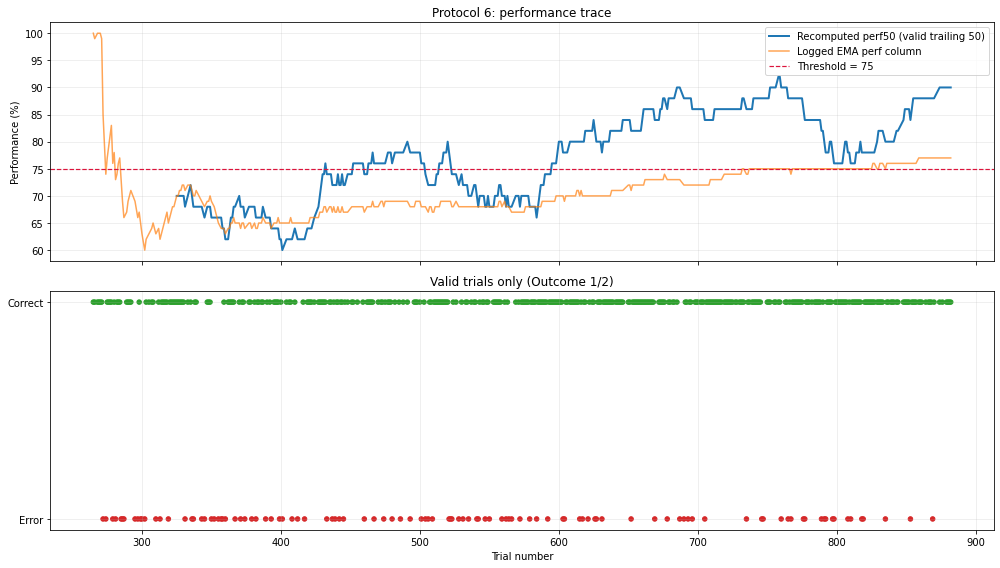

In [21]:
if selected_protocol_valid_rows:
    trial_nums = np.array([r["trial_num"] for r in selected_protocol_valid_rows], dtype=int)
    perf50_vals = np.array([r["perf50_valid"] for r in selected_protocol_valid_rows], dtype=float)
    logged_perf_vals = np.array([r["logged_perf_ema"] for r in selected_protocol_valid_rows], dtype=float)
    correct_vals = np.array([1 if r["outcome"] == 1 else 0 for r in selected_protocol_valid_rows], dtype=float)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(trial_nums, perf50_vals, color="#1f77b4", lw=2, label="Recomputed perf50 (valid trailing 50)")
    axes[0].plot(trial_nums, logged_perf_vals, color="#ff7f0e", lw=1.5, alpha=0.7, label="Logged EMA perf column")
    axes[0].axhline(PERF50_THRESHOLD, color="crimson", ls="--", lw=1.2, label=f"Threshold = {PERF50_THRESHOLD:.0f}")
    axes[0].set_ylabel("Performance (%)")
    axes[0].set_title(f"Protocol {PROTOCOL_OF_INTEREST}: performance trace")
    axes[0].legend(loc="best")
    axes[0].grid(alpha=0.25)

    axes[1].scatter(trial_nums, correct_vals, s=20, c=np.where(correct_vals > 0.5, "#2ca02c", "#d62728"))
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(["Error", "Correct"])
    axes[1].set_xlabel("Trial number")
    axes[1].set_title("Valid trials only (Outcome 1/2)")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No valid trials (Outcome 1/2) were found for the selected protocol.")


In [22]:
if INCLUDE_ERROR_TRIALS_IN_DECODING:
    analysis_rows = [
        r for r in selected_protocol_valid_rows
        if r["choice"] in (1, 2) and r["passes_perf50"]
    ]
else:
    analysis_rows = [
        r for r in selected_protocol_valid_rows
        if r["outcome"] == 1 and r["trial_type"] in (1, 2) and r["passes_perf50"]
    ]

choice_counts = {
    "Left": sum(r["choice"] == 1 for r in analysis_rows),
    "Right": sum(r["choice"] == 2 for r in analysis_rows),
}
outcome_counts = {
    "Correct": sum(r["outcome"] == 1 for r in analysis_rows),
    "Error": sum(r["outcome"] == 2 for r in analysis_rows),
}

print(f"Trials entering decoding: {len(analysis_rows)}")
print(f"Choice counts:            {choice_counts}")
print(f"Outcome counts:           {outcome_counts}")
print(f"Selected channels:        {SELECTED_LFP_CHANNELS}")
print(f"Display mode:             {DISPLAY_CHANNEL_LABEL}")
print("Time-resolved decoding uses selected_lfp_channels as features.")
if analysis_rows:
    print(f"First passing trial:      {analysis_rows[0]['trial_num']}")
    print(f"Last passing trial:       {analysis_rows[-1]['trial_num']}")
    print(f"Perf50 range in set:      {min(r['perf50_valid'] for r in analysis_rows):.1f} - {max(r['perf50_valid'] for r in analysis_rows):.1f}")


Trials entering decoding: 235
Choice counts:            {'Left': 137, 'Right': 98}
Outcome counts:           {'Correct': 235, 'Error': 0}
Selected channels:        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Display mode:             all selected channels (shown separately)
Time-resolved decoding uses selected_lfp_channels as features.
First passing trial:      432
Last passing trial:       882
Perf50 range in set:      76.0 - 92.0


In [23]:
def parse_trial_key(key: str):
    key = str(key)
    match = re.search(r"Trial_(\d+)$", key)
    if match:
        trial_num = int(match.group(1))
        session = key[:match.start()].rstrip("_")
        return trial_num, (session if session else "single_session")
    if key.isdigit():
        return int(key), "single_session"
    raise ValueError(f"Unsupported H5 key format: {key}")


def build_h5_index(path: Path):
    index = []
    with h5py.File(path, "r") as h5_file:
        for key in sorted(h5_file.keys()):
            trial_num, session = parse_trial_key(key)
            index.append({
                "trial_key": key,
                "trial_num": trial_num,
                "session": session,
            })
    return index


H5_READY = H5_PATH.exists()
analysis_records = []
missing_in_h5 = []

if H5_READY:
    h5_index = build_h5_index(H5_PATH)
    h5_by_trial = {}
    for item in h5_index:
        h5_by_trial.setdefault(item["trial_num"], []).append(item)

    for row in analysis_rows:
        candidates = h5_by_trial.get(row["trial_num"], [])
        if not candidates:
            missing_in_h5.append(row["trial_num"])
            continue
        record = dict(row)
        record.update(candidates[0])
        analysis_records.append(record)

    print(f"H5 groups found:        {len(h5_index)}")
    print(f"Trials matched to H5:   {len(analysis_records)}")
    print(f"Trials missing from H5: {len(missing_in_h5)}")
    if missing_in_h5:
        print(f"First missing trial numbers: {missing_in_h5[:10]}")
else:
    print(f"Configured H5 not found yet: {H5_PATH}")
    print("Please point USER_CONFIG['protocol_to_h5'] or USER_CONFIG['default_h5_path'] to the correct file, then rerun the next cells.")


H5 groups found:        572
Trials matched to H5:   235
Trials missing from H5: 0


In [24]:
def slice_window(time_ms: np.ndarray, values: np.ndarray, window_ms):
    mask = (time_ms >= window_ms[0]) & (time_ms < window_ms[1])
    if values.ndim == 1:
        return time_ms[mask], values[mask]
    return time_ms[mask], values[:, mask]


def infer_fs(time_ms: np.ndarray) -> float:
    if time_ms.size < 2:
        raise ValueError("Need at least two time samples to infer sampling rate.")
    return 1000.0 / float(np.median(np.diff(time_ms)))


def sanitize_features(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=1e6, neginf=-1e6)
    return np.clip(x, -1e6, 1e6)


def preprocess_lfp_window(lfp_t, lfp_v, window_ms, selected_channels, median_reference):
    time_ms, full_window = slice_window(lfp_t, lfp_v, window_ms)
    if time_ms.size < 16:
        raise ValueError(f"Window {window_ms} is too short for stable processing.")
    signal_window = full_window[list(selected_channels)].astype(float)
    if median_reference:
        signal_window = signal_window - np.median(full_window, axis=0, keepdims=True)
    signal_window = signal.detrend(signal_window, axis=-1, type="constant")
    return time_ms, signal_window


def normalize_trace(trace, time_ms, mode, baseline_window_ms):
    trace = np.asarray(trace, dtype=float)
    time_ms = np.asarray(time_ms, dtype=float)
    if mode == "none":
        return trace

    baseline_mask = (time_ms >= baseline_window_ms[0]) & (time_ms <= baseline_window_ms[1]) & np.isfinite(trace)
    if not np.any(baseline_mask):
        return np.full(trace.shape, np.nan, dtype=float)

    baseline_vals = trace[baseline_mask]
    baseline_mean = float(np.nanmean(baseline_vals))

    if mode == "zscore":
        baseline_std = float(np.nanstd(baseline_vals, ddof=1))
        if not np.isfinite(baseline_std) or baseline_std < 1e-12:
            return np.full(trace.shape, np.nan, dtype=float)
        return (trace - baseline_mean) / baseline_std

    if mode == "db":
        if not np.isfinite(baseline_mean) or baseline_mean <= 0:
            return np.full(trace.shape, np.nan, dtype=float)
        safe_trace = np.where(trace > 0, trace, np.nan)
        return 10.0 * np.log10(safe_trace / baseline_mean)

    raise ValueError(f"Unsupported normalization mode: {mode}")


def interpolate_with_nan(target_t, source_t, source_v):
    target_t = np.asarray(target_t, dtype=float)
    source_t = np.asarray(source_t, dtype=float)
    source_v = np.asarray(source_v, dtype=float)
    out = np.full(target_t.shape, np.nan, dtype=float)
    valid_mask = (target_t >= source_t[0]) & (target_t <= source_t[-1])
    if np.any(valid_mask):
        out[valid_mask] = np.interp(target_t[valid_mask], source_t, source_v)
    return out


def nansem(x, axis=0):
    x = np.asarray(x, dtype=float)
    valid_n = np.sum(np.isfinite(x), axis=axis)
    std = np.nanstd(x, axis=axis, ddof=1)
    return std / np.sqrt(np.maximum(valid_n, 1))


def pointwise_left_right_significance(left_traces, right_traces, alpha=0.05, min_trials_per_group=3):
    left_traces = np.asarray(left_traces, dtype=float)
    right_traces = np.asarray(right_traces, dtype=float)
    if left_traces.ndim != 2 or right_traces.ndim != 2:
        raise ValueError("left_traces and right_traces must be 2D arrays: [n_trials, n_timepoints].")
    if left_traces.shape[1] != right_traces.shape[1]:
        raise ValueError("left_traces and right_traces must share the same number of timepoints.")

    pvals = np.full(left_traces.shape[1], np.nan, dtype=float)
    for t_idx in range(left_traces.shape[1]):
        left_vals = left_traces[:, t_idx]
        right_vals = right_traces[:, t_idx]
        left_vals = left_vals[np.isfinite(left_vals)]
        right_vals = right_vals[np.isfinite(right_vals)]

        if left_vals.size < min_trials_per_group or right_vals.size < min_trials_per_group:
            continue

        pvals[t_idx] = stats.ttest_ind(left_vals, right_vals, equal_var=False).pvalue

    sig_mask = np.isfinite(pvals) & (pvals < alpha)
    return pvals, sig_mask


def extract_lfp_features(lfp_t, lfp_v, window_ms, selected_channels, median_reference, bands):
    time_ms, signal_window = preprocess_lfp_window(
        lfp_t=lfp_t,
        lfp_v=lfp_v,
        window_ms=window_ms,
        selected_channels=selected_channels,
        median_reference=median_reference,
    )
    fs = infer_fs(time_ms)

    feats = []
    for ch_idx in range(signal_window.shape[0]):
        freqs, pxx = signal.welch(
            signal_window[ch_idx],
            fs=fs,
            nperseg=min(signal_window.shape[1], max(64, int(fs * 0.25))),
        )
        for _, (f_low, f_high) in bands:
            mask = (freqs >= f_low) & (freqs < f_high)
            band_power = np.trapz(pxx[mask], freqs[mask]) if np.any(mask) else 0.0
            feats.append(np.log10(band_power + 1e-12))
        feats.append(float(np.mean(signal_window[ch_idx])))
        feats.append(float(np.std(signal_window[ch_idx])))
    return sanitize_features(np.asarray(feats, dtype=float))


def compute_trial_band_energy_data(
    lfp_t,
    lfp_v,
    plot_window_ms,
    baseline_window_ms,
    normalization_mode,
    selected_channels,
    display_channel_mode,
    median_reference,
    bands,
    resample_step_ms,
):
    time_ms, signal_window = preprocess_lfp_window(
        lfp_t=lfp_t,
        lfp_v=lfp_v,
        window_ms=plot_window_ms,
        selected_channels=selected_channels,
        median_reference=median_reference,
    )
    fs = infer_fs(time_ms)
    common_t = np.arange(plot_window_ms[0], plot_window_ms[1] + resample_step_ms * 0.5, resample_step_ms)

    if display_channel_mode == "mean_selected":
        display_selector = None
    else:
        display_selector = list(selected_channels).index(int(display_channel_mode))

    out = {}
    for band_name, (f_low, f_high) in bands:
        b, a = signal.butter(3, [f_low, f_high], btype="bandpass", fs=fs)
        band_signal = signal.filtfilt(b, a, signal_window, axis=-1)
        band_power = np.abs(signal.hilbert(band_signal, axis=-1)) ** 2

        interp_channels = []
        for ch_idx in range(band_power.shape[0]):
            interp_trace = interpolate_with_nan(common_t, time_ms, band_power[ch_idx])
            interp_trace = normalize_trace(interp_trace, common_t, normalization_mode, baseline_window_ms)
            interp_channels.append(interp_trace)
        channel_matrix = np.asarray(interp_channels, dtype=float)

        if display_selector is None:
            display_trace = np.nanmean(channel_matrix, axis=0)
        else:
            display_trace = channel_matrix[display_selector]

        out[band_name] = {
            "channel_matrix": channel_matrix,
            "display_trace": display_trace,
        }

    return common_t, out


def build_cv_splits(y, groups):
    y = np.asarray(y, dtype=int)
    groups = np.asarray(groups)
    class_counts = np.bincount(y, minlength=2)
    if np.min(class_counts) < 2:
        raise ValueError("Need at least two trials in each class for decoding.")

    unique_groups = np.unique(groups)
    if unique_groups.size >= 3:
        splitter = GroupKFold(n_splits=min(5, unique_groups.size))
        splits = list(splitter.split(np.zeros_like(y), y, groups=groups))
        split_name = f"GroupKFold(n_splits={splitter.n_splits})"
    else:
        n_splits = int(min(5, np.min(class_counts)))
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        splits = list(splitter.split(np.zeros_like(y), y))
        split_name = f"StratifiedKFold(n_splits={n_splits})"
    return splits, split_name


def run_time_resolved_decoding(feature_tensor, y, groups, metric_name):
    feature_tensor = np.asarray(feature_tensor, dtype=float)
    y = np.asarray(y, dtype=int)
    splits, split_name = build_cv_splits(y, groups)
    n_trials, n_features, n_times = feature_tensor.shape
    pred = np.full((n_trials, n_times), np.nan)
    prob = np.full((n_trials, n_times), np.nan)

    for t_idx in range(n_times):
        X_t = sanitize_features(feature_tensor[:, :, t_idx])
        for train_idx, test_idx in splits:
            clf = make_pipeline(
                StandardScaler(),
                LogisticRegression(
                    max_iter=5000,
                    solver="lbfgs",
                    class_weight="balanced",
                    random_state=42,
                ),
            )
            clf.fit(X_t[train_idx], y[train_idx])
            pred[test_idx, t_idx] = clf.predict(X_t[test_idx])
            prob[test_idx, t_idx] = clf.predict_proba(X_t[test_idx])[:, 1]

    perf = np.full(n_times, np.nan)
    for t_idx in range(n_times):
        pred_t = pred[:, t_idx]
        valid_mask = np.isfinite(pred_t)
        if not np.any(valid_mask):
            continue
        pred_int = pred_t[valid_mask].astype(int)
        y_valid = y[valid_mask]
        if metric_name == "accuracy":
            perf[t_idx] = accuracy_score(y_valid, pred_int)
        else:
            perf[t_idx] = balanced_accuracy_score(y_valid, pred_int)

    return {
        "split_name": split_name,
        "metric_name": metric_name,
        "performance": perf,
        "pred": pred,
        "prob": prob,
    }


def run_whole_window_decoder(X, y, groups):
    y = np.asarray(y, dtype=int)
    splits, split_name = build_cv_splits(y, groups)
    pred = np.full(y.shape, np.nan)
    prob = np.full(y.shape, np.nan)
    X = sanitize_features(X)

    for train_idx, test_idx in splits:
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=5000,
                solver="lbfgs",
                class_weight="balanced",
                random_state=42,
            ),
        )
        clf.fit(X[train_idx], y[train_idx])
        pred[test_idx] = clf.predict(X[test_idx])
        prob[test_idx] = clf.predict_proba(X[test_idx])[:, 1]

    pred_int = pred.astype(int)
    return {
        "split_name": split_name,
        "pred": pred_int,
        "prob": prob,
        "accuracy": float(accuracy_score(y, pred_int)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred_int)),
        "confusion_matrix": confusion_matrix(y, pred_int),
    }


C:\Users\Administrator\AppData\Local\Temp\ipykernel_47364\3555341283.py:168: RuntimeWarning: Mean of empty slice
  display_trace = np.nanmean(channel_matrix, axis=0)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_47364\3138175664.py:83: RuntimeWarning: Mean of empty slice
  mean_trace = np.nanmean(traces, axis=0)
d:\anaconda\envs\Habits\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


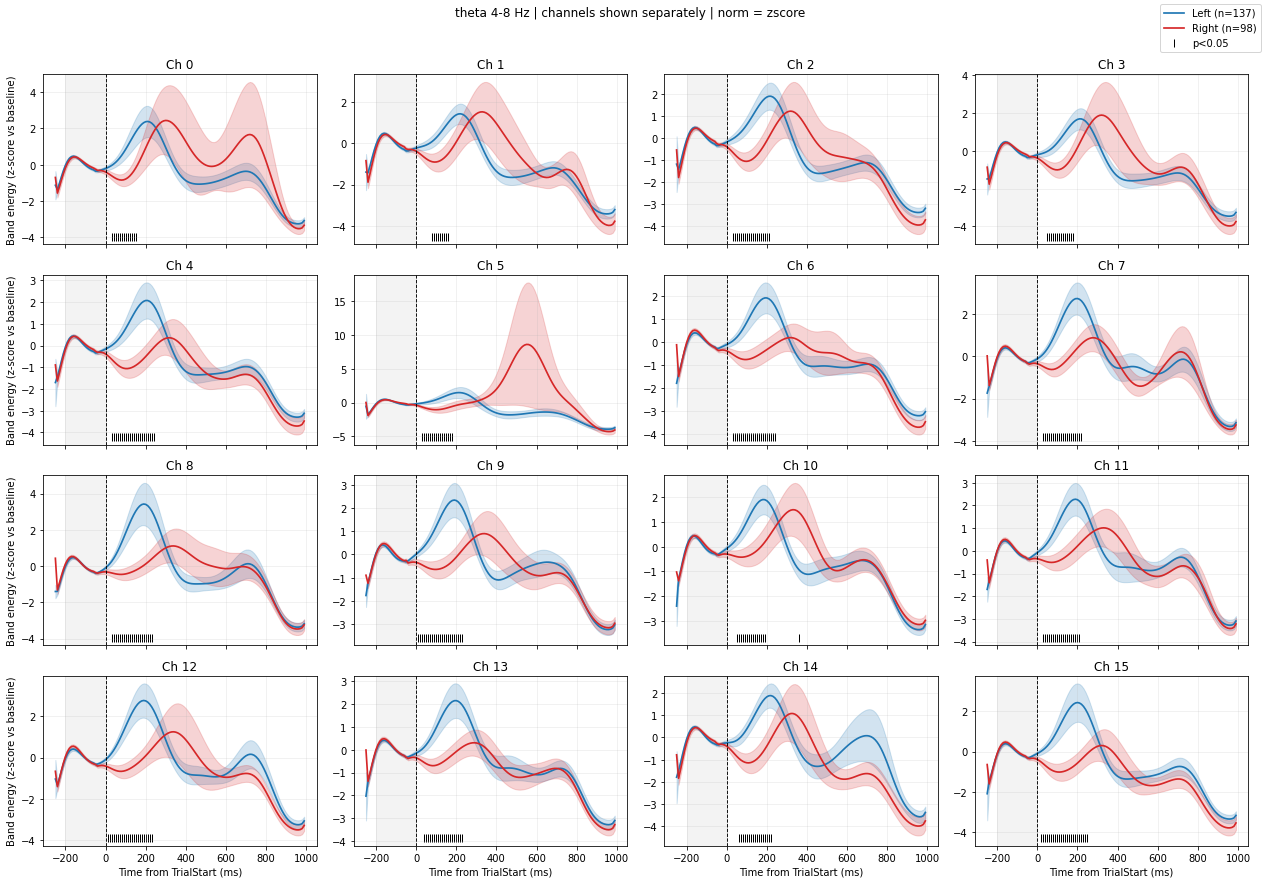

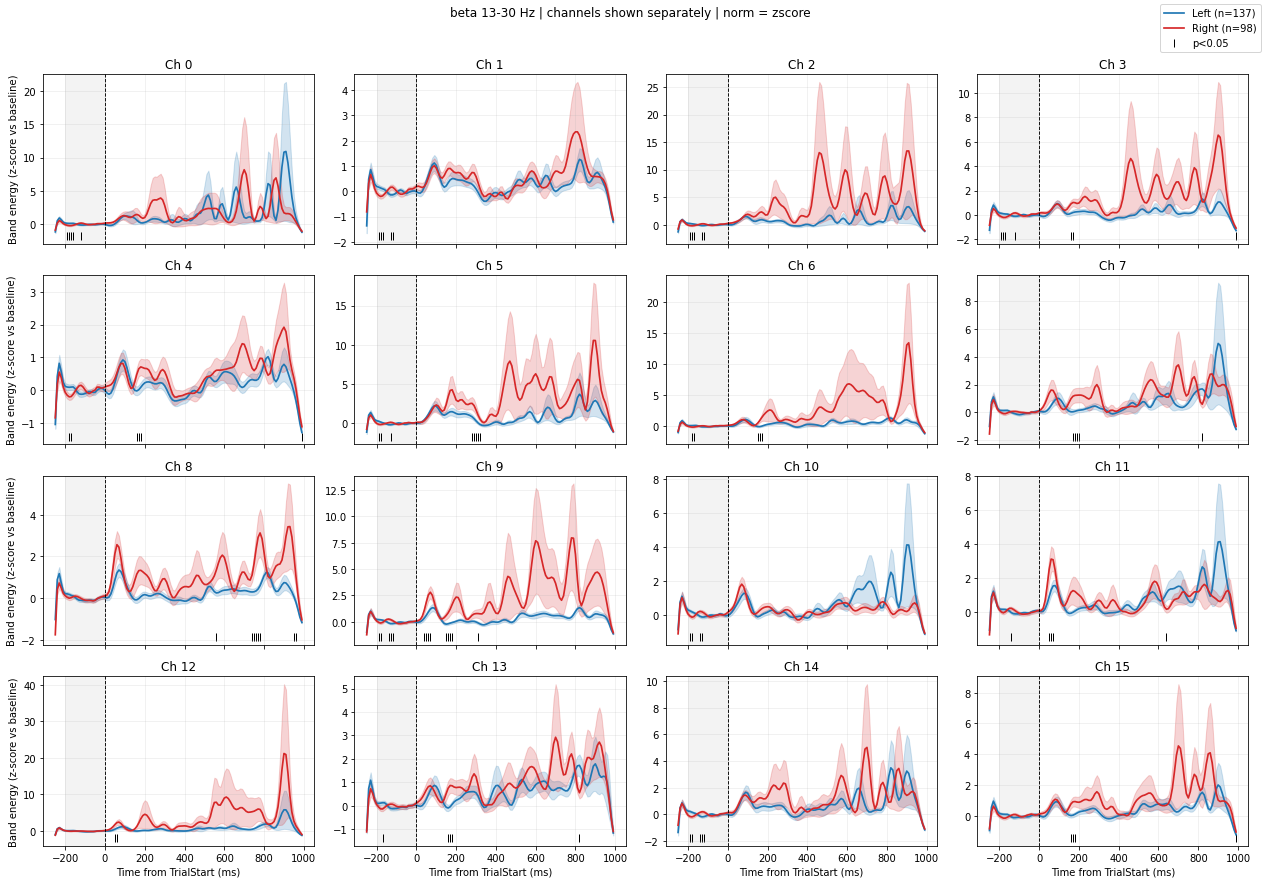

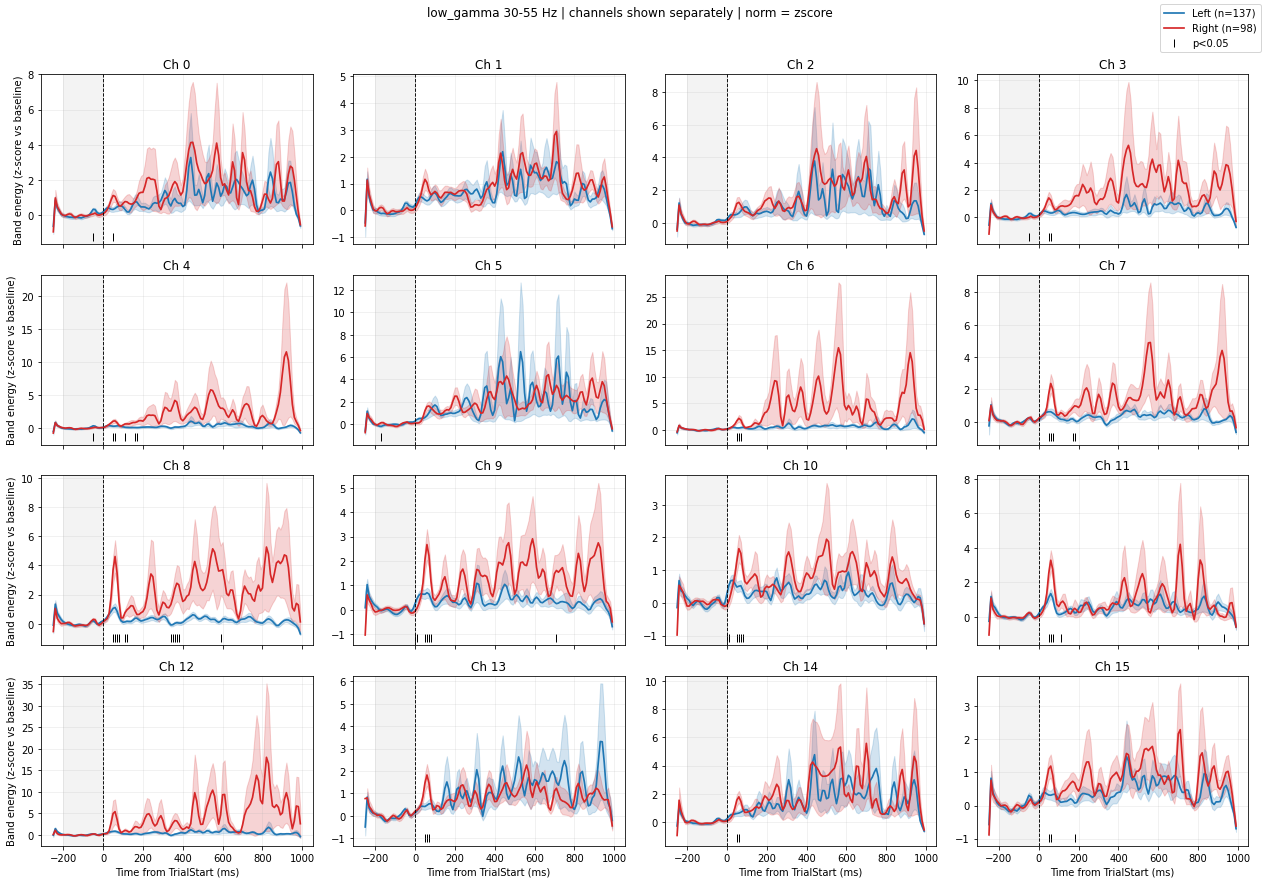

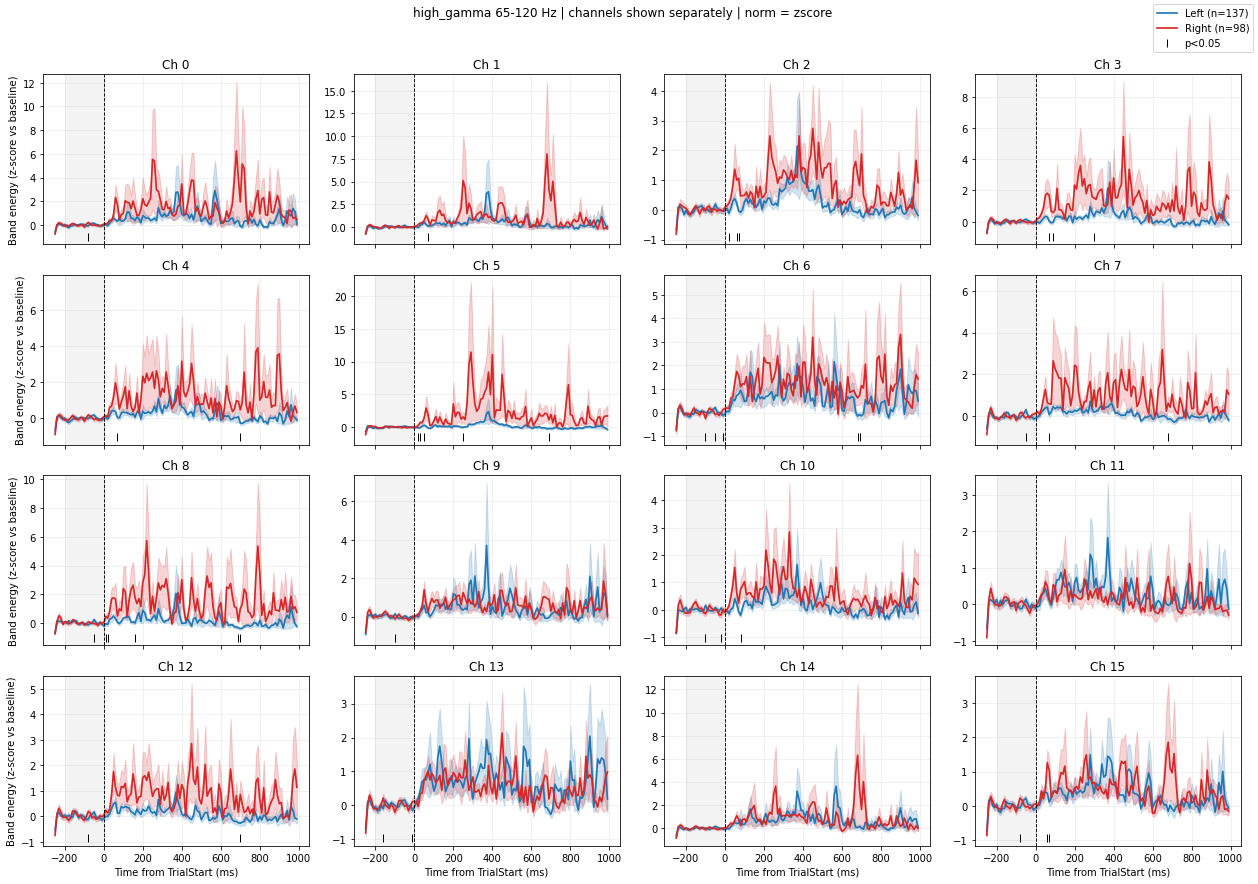

In [25]:
band_dataset = None
decode_y = None
decode_groups = None
decode_trial_nums = None

if not analysis_records:
    print("No H5-backed trials are available yet for band-energy visualization and time-resolved decoding.")
else:
    common_t_ref = None
    band_dataset = {
        band_name: {"feature_tensors": []}
        for band_name, _ in LFP_BANDS
    }
    decode_y = []
    decode_groups = []
    decode_trial_nums = []

    with h5py.File(H5_PATH, "r") as h5_file:
        for rec in analysis_records:
            grp = h5_file[rec["trial_key"]]
            lfp_t = np.array(grp["lfp_t"])
            lfp_v = np.array(grp["lfp_v"])

            common_t, band_data = compute_trial_band_energy_data(
                lfp_t=lfp_t,
                lfp_v=lfp_v,
                plot_window_ms=BAND_ENERGY_PLOT_WINDOW_MS,
                baseline_window_ms=BAND_ENERGY_BASELINE_WINDOW_MS,
                normalization_mode=BAND_ENERGY_NORMALIZATION,
                selected_channels=SELECTED_LFP_CHANNELS,
                display_channel_mode=DISPLAY_CHANNEL_MODE,
                median_reference=MEDIAN_REFERENCE,
                bands=LFP_BANDS,
                resample_step_ms=BAND_ENERGY_RESAMPLE_STEP_MS,
            )

            if common_t_ref is None:
                common_t_ref = common_t

            for band_name, _ in LFP_BANDS:
                band_dataset[band_name]["feature_tensors"].append(band_data[band_name]["channel_matrix"])

            decode_y.append(1 if rec["choice"] == 2 else 0)
            decode_groups.append(rec["session"])
            decode_trial_nums.append(rec["trial_num"])

    for band_name, _ in LFP_BANDS:
        band_dataset[band_name]["feature_tensors"] = np.asarray(band_dataset[band_name]["feature_tensors"], dtype=float)

    band_dataset["time_ms"] = common_t_ref
    decode_y = np.asarray(decode_y, dtype=int)
    decode_groups = np.asarray(decode_groups)
    decode_trial_nums = np.asarray(decode_trial_nums, dtype=int)

    if BAND_ENERGY_NORMALIZATION == "none":
        y_label = "Band energy (a.u.)"
    elif BAND_ENERGY_NORMALIZATION == "zscore":
        y_label = "Band energy (z-score vs baseline)"
    else:
        y_label = "Band energy (dB change vs baseline)"

    color_map = {0: "#1f77b4", 1: "#d62728"}
    label_map = {0: "Left", 1: "Right"}

    for band_name, band_range in LFP_BANDS:
        feature_tensor = band_dataset[band_name]["feature_tensors"]
        n_channels = feature_tensor.shape[1]
        n_cols = min(4, n_channels)
        n_rows = int(np.ceil(n_channels / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.0 * n_rows), sharex=True)
        axes = np.atleast_1d(axes).ravel()

        for ch_idx in range(n_channels):
            ax = axes[ch_idx]
            traces_ch = feature_tensor[:, ch_idx, :]
            left_traces = traces_ch[decode_y == 0]
            right_traces = traces_ch[decode_y == 1]

            for y_value in (0, 1):
                traces = traces_ch[decode_y == y_value]
                if traces.size == 0:
                    continue
                mean_trace = np.nanmean(traces, axis=0)
                sem_trace = nansem(traces, axis=0)
                ax.plot(common_t_ref, mean_trace, color=color_map[y_value], lw=1.7, label=f"{label_map[y_value]} (n={traces.shape[0]})")
                ax.fill_between(common_t_ref, mean_trace - sem_trace, mean_trace + sem_trace, color=color_map[y_value], alpha=0.2)

            ax.axvline(0, color="black", ls="--", lw=0.9)
            ax.axvspan(BAND_ENERGY_BASELINE_WINDOW_MS[0], BAND_ENERGY_BASELINE_WINDOW_MS[1], color="0.85", alpha=0.3, zorder=0)
            _, sig_mask = pointwise_left_right_significance(left_traces, right_traces, alpha=0.05, min_trials_per_group=3)
            if np.any(sig_mask):
                y_min, y_max = ax.get_ylim()
                y_sig = y_min + 0.03 * (y_max - y_min)
                ax.scatter(
                    common_t_ref[sig_mask],
                    np.full(np.sum(sig_mask), y_sig),
                    marker="|",
                    s=55,
                    linewidths=1.0,
                    color="black",
                    label="p<0.05",
                )
            ax.set_title(f"Ch {SELECTED_LFP_CHANNELS[ch_idx]}")
            ax.grid(alpha=0.22)

        for ax in axes[n_channels:]:
            ax.axis("off")

        for ax in axes[-n_cols:]:
            ax.set_xlabel("Time from TrialStart (ms)")
        for row_start in range(0, n_channels, n_cols):
            axes[row_start].set_ylabel(y_label)

        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="upper right")
        fig.suptitle(
            f"{band_name} {band_range[0]:.0f}-{band_range[1]:.0f} Hz | channels shown separately | norm = {BAND_ENERGY_NORMALIZATION}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


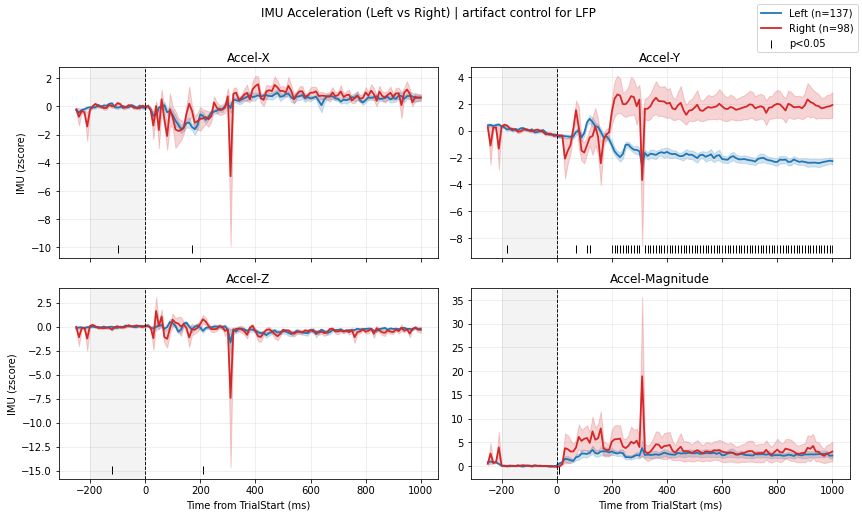

IMU keys: time='sen_t', value='sen_v', trials=235
sen_labels (first trial): ['AcclX', 'AcclY', 'AcclZ', 'GryoX', 'GryoY', 'GryoZ', 'RSOC', 'Battery_STAT', 'Battery_voltage', 'UpdateFlag']


In [26]:
if not analysis_records:
    print("No H5-backed trials are available yet for IMU visualization.")
else:
    # Follow data_processing.py definition:
    # sensor/IMU is saved as sen_t, sen_v and channel names in attr sen_labels.
    imu_time_key = "sen_t"
    imu_value_key = "sen_v"

    with h5py.File(H5_PATH, "r") as h5_file:
        first_grp = h5_file[analysis_records[0]["trial_key"]]
        if imu_time_key not in first_grp or imu_value_key not in first_grp:
            print("sen_t/sen_v not found in H5 trial group.")
            print(f"Available keys: {list(first_grp.keys())}")
        else:
            imu_t_ref = np.arange(
                BAND_ENERGY_PLOT_WINDOW_MS[0],
                BAND_ENERGY_PLOT_WINDOW_MS[1] + BAND_ENERGY_RESAMPLE_STEP_MS * 0.5,
                BAND_ENERGY_RESAMPLE_STEP_MS,
            )

            # dB is not suitable for signed acceleration; fallback to z-score baseline.
            imu_norm_mode = BAND_ENERGY_NORMALIZATION if BAND_ENERGY_NORMALIZATION != "db" else "zscore"

            imu_xyz_trials = []
            imu_mag_trials = []
            imu_y = []

            for rec in analysis_records:
                grp = h5_file[rec["trial_key"]]
                if imu_time_key not in grp or imu_value_key not in grp:
                    continue

                sen_labels = list(grp.attrs.get("sen_labels", []))
                if isinstance(sen_labels, str):
                    try:
                        sen_labels = eval(sen_labels)
                    except Exception:
                        sen_labels = []

                imu_t = np.asarray(grp[imu_time_key], dtype=float).reshape(-1)
                imu_v = np.asarray(grp[imu_value_key], dtype=float)
                if imu_t.size < 2 or imu_v.ndim != 2:
                    continue

                # data_processing.py saves sen_v as [channels, time], keep robust transpose handling.
                if imu_v.shape[0] <= imu_v.shape[1]:
                    sen_ct = imu_v
                else:
                    sen_ct = imu_v.T

                # Pick 3 accel axes by label if possible.
                accel_idx = []
                if sen_labels:
                    for i, lb in enumerate(sen_labels):
                        lb_l = str(lb).lower()
                        if ("acc" in lb_l or "imu" in lb_l) and len(accel_idx) < 3:
                            accel_idx.append(i)

                if len(accel_idx) < 3:
                    accel_idx = list(range(min(3, sen_ct.shape[0])))

                if len(accel_idx) < 3:
                    continue

                imu_xyz = sen_ct[accel_idx, :]

                xyz_interp = []
                for axis_idx in range(3):
                    trace = interpolate_with_nan(imu_t_ref, imu_t, imu_xyz[axis_idx])
                    trace = normalize_trace(trace, imu_t_ref, imu_norm_mode, BAND_ENERGY_BASELINE_WINDOW_MS)
                    xyz_interp.append(trace)
                xyz_interp = np.asarray(xyz_interp, dtype=float)

                mag = np.sqrt(np.sum(np.square(xyz_interp), axis=0))
                mag = normalize_trace(mag, imu_t_ref, imu_norm_mode, BAND_ENERGY_BASELINE_WINDOW_MS)

                imu_xyz_trials.append(xyz_interp)
                imu_mag_trials.append(mag)
                imu_y.append(1 if rec["choice"] == 2 else 0)

            if not imu_xyz_trials:
                print("No valid IMU/Accel trials were found after parsing shape/time constraints.")
                print(f"Using keys: time='{imu_time_key}', value='{imu_value_key}'")
                print(f"sen_labels (first trial): {first_grp.attrs.get('sen_labels', 'N/A')}")
            else:
                imu_xyz_trials = np.asarray(imu_xyz_trials, dtype=float)  # [n_trials, 3, n_time]
                imu_mag_trials = np.asarray(imu_mag_trials, dtype=float)  # [n_trials, n_time]
                imu_y = np.asarray(imu_y, dtype=int)

                axis_names = ["Accel-X", "Accel-Y", "Accel-Z", "Accel-Magnitude"]
                color_map = {0: "#1f77b4", 1: "#d62728"}
                label_map = {0: "Left", 1: "Right"}

                fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
                axes = axes.ravel()

                for axis_idx in range(4):
                    ax = axes[axis_idx]
                    traces_axis = imu_xyz_trials[:, axis_idx, :] if axis_idx < 3 else imu_mag_trials
                    left_traces = traces_axis[imu_y == 0]
                    right_traces = traces_axis[imu_y == 1]

                    for y_value in (0, 1):
                        traces = traces_axis[imu_y == y_value]
                        if traces.size == 0:
                            continue
                        mean_trace = np.nanmean(traces, axis=0)
                        sem_trace = nansem(traces, axis=0)
                        ax.plot(imu_t_ref, mean_trace, color=color_map[y_value], lw=1.8, label=f"{label_map[y_value]} (n={traces.shape[0]})")
                        ax.fill_between(imu_t_ref, mean_trace - sem_trace, mean_trace + sem_trace, color=color_map[y_value], alpha=0.2)

                    _, sig_mask = pointwise_left_right_significance(left_traces, right_traces, alpha=0.05, min_trials_per_group=3)
                    if np.any(sig_mask):
                        y_min, y_max = ax.get_ylim()
                        y_sig = y_min + 0.03 * (y_max - y_min)
                        ax.scatter(
                            imu_t_ref[sig_mask],
                            np.full(np.sum(sig_mask), y_sig),
                            marker="|",
                            s=55,
                            linewidths=1.0,
                            color="black",
                            label="p<0.05",
                        )

                    ax.axvline(0, color="black", ls="--", lw=0.9)
                    ax.axvspan(BAND_ENERGY_BASELINE_WINDOW_MS[0], BAND_ENERGY_BASELINE_WINDOW_MS[1], color="0.85", alpha=0.3, zorder=0)
                    ax.set_title(axis_names[axis_idx])
                    ax.grid(alpha=0.25)

                for ax in axes[2:]:
                    ax.set_xlabel("Time from TrialStart (ms)")
                axes[0].set_ylabel(f"IMU ({imu_norm_mode})")
                axes[2].set_ylabel(f"IMU ({imu_norm_mode})")

                handles, labels = axes[0].get_legend_handles_labels()
                if handles:
                    fig.legend(handles, labels, loc="upper right")
                fig.suptitle("IMU Acceleration (Left vs Right) | artifact control for LFP", y=1.02)
                plt.tight_layout()
                plt.show()

                print(f"IMU keys: time='{imu_time_key}', value='{imu_value_key}', trials={imu_xyz_trials.shape[0]}")
                print(f"sen_labels (first trial): {first_grp.attrs.get('sen_labels', 'N/A')}")


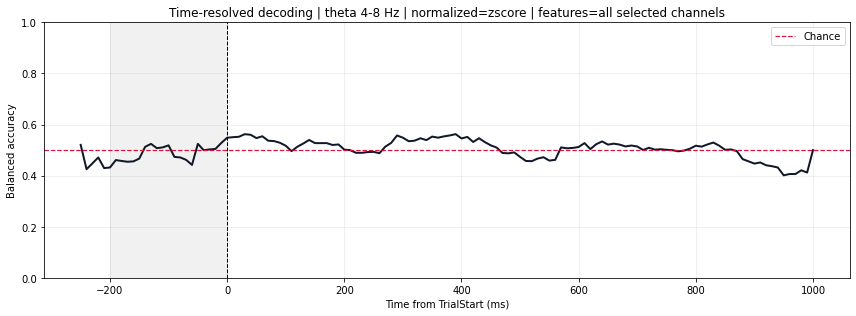

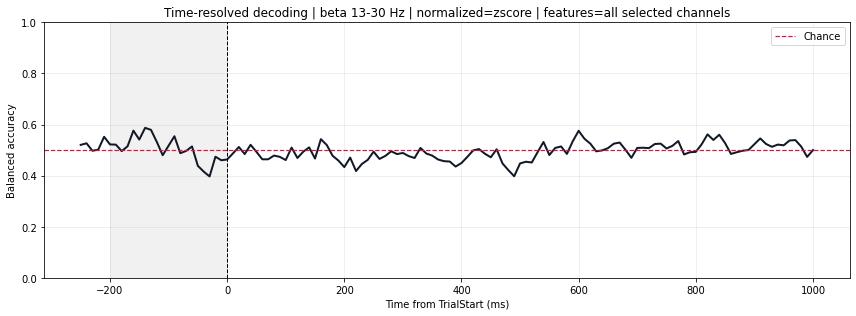

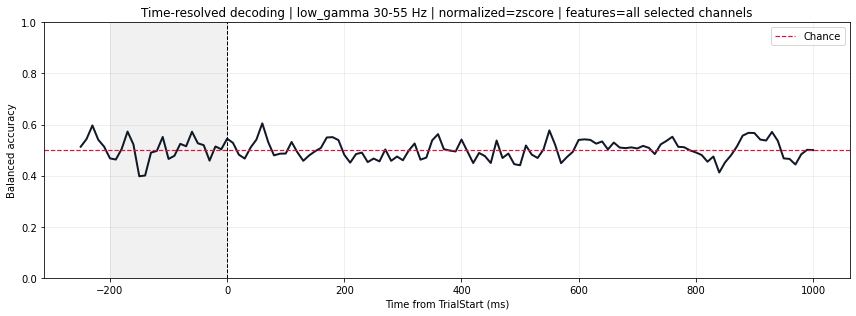

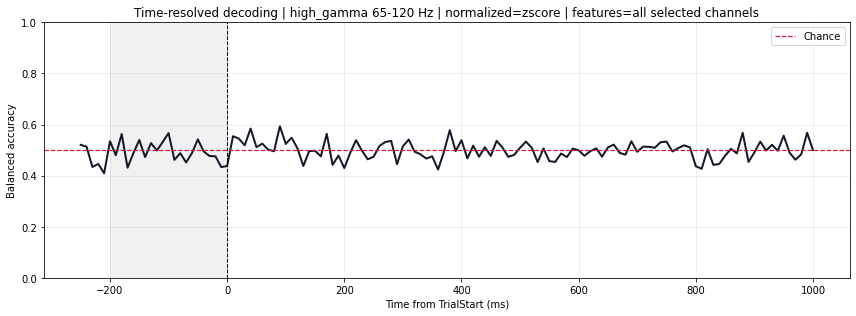

Time-resolved splitter: GroupKFold(n_splits=5)
Metric:                balanced_accuracy
Feature source:        normalized band-energy (zscore), no channel averaging


In [27]:
time_resolved_results = None

if band_dataset is None:
    print("Time-resolved decoding is not ready yet because band_dataset is unavailable.")
else:
    time_resolved_results = {}
    metric_ylabel = "Balanced accuracy" if TIME_RESOLVED_METRIC == "balanced_accuracy" else "Accuracy"
    chance_level = 0.5
    common_t_ref = band_dataset["time_ms"]

    for band_name, band_range in LFP_BANDS:
        feature_tensor = band_dataset[band_name]["feature_tensors"]
        result = run_time_resolved_decoding(feature_tensor, decode_y, decode_groups, TIME_RESOLVED_METRIC)
        time_resolved_results[band_name] = result

        fig, ax = plt.subplots(figsize=(12, 4.5))
        ax.plot(common_t_ref, result["performance"], color="#111827", lw=2)
        ax.axhline(chance_level, color="crimson", ls="--", lw=1.2, label="Chance")
        ax.axvline(0, color="black", ls="--", lw=1)
        ax.axvspan(BAND_ENERGY_BASELINE_WINDOW_MS[0], BAND_ENERGY_BASELINE_WINDOW_MS[1], color="0.85", alpha=0.35, zorder=0)
        ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Time from TrialStart (ms)")
        ax.set_ylabel(metric_ylabel)
        ax.set_title(
            f"Time-resolved decoding | {band_name} {band_range[0]:.0f}-{band_range[1]:.0f} Hz | normalized={BAND_ENERGY_NORMALIZATION} | features=all selected channels"
        )
        ax.grid(alpha=0.25)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()

    first_band = LFP_BANDS[0][0]
    print(f"Time-resolved splitter: {time_resolved_results[first_band]['split_name']}")
    print(f"Metric:                {TIME_RESOLVED_METRIC}")
    print(f"Feature source:        normalized band-energy ({BAND_ENERGY_NORMALIZATION}), no channel averaging")


In [28]:
X = None
y = None
trial_num_vector = None
group_vector = None

if band_dataset is None:
    print("No normalized band-energy dataset is available yet for whole-window decoding.")
else:
    feature_blocks = []
    for band_name, _ in LFP_BANDS:
        tensor = band_dataset[band_name]["feature_tensors"]  # [n_trials, n_channels, n_timepoints]
        feature_blocks.append(tensor.reshape(tensor.shape[0], -1))

    X = np.hstack(feature_blocks)
    y = decode_y.copy()
    trial_num_vector = decode_trial_nums.copy()
    group_vector = decode_groups.copy()

    print(f"Whole-window feature source: normalized band-energy ({BAND_ENERGY_NORMALIZATION})")
    print(f"Feature matrix shape:         {X.shape}")
    print(f"Bands used:                   {[name for name, _ in LFP_BANDS]}")
    print(f"Channels used:                {SELECTED_LFP_CHANNELS}")
    print(f"Left trials:                  {int(np.sum(y == 0))}")
    print(f"Right trials:                 {int(np.sum(y == 1))}")
    print(f"Unique sessions:              {np.unique(group_vector).tolist()}")


Whole-window feature source: normalized band-energy (zscore)
Feature matrix shape:         (235, 8064)
Bands used:                   ['theta', 'beta', 'low_gamma', 'high_gamma']
Channels used:                [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Left trials:                  137
Right trials:                 98
Unique sessions:              ['2026-04-02-02-11-12', '2026-04-02-03-33-02', '2026-04-02-03-34-06', '2026-04-02-03-36-14', '2026-04-02-03-37-08', '2026-04-02-03-46-26', '2026-04-02-03-47-46', '2026-04-02-04-07-16', '2026-04-02-04-11-44', '2026-04-02-05-39-52', '2026-04-02-05-42-33', '2026-04-02-05-45-29', '2026-04-02-05-50-22', '2026-04-02-16-44-24', '2026-04-02-16-57-29', '2026-04-02-17-10-36', '2026-04-02-17-35-02', '2026-04-02-17-50-54', '2026-04-02-18-24-01', '2026-04-02-18-34-24', '2026-04-02-18-56-27', '2026-04-02-20-16-13', '2026-04-02-20-26-03', '2026-04-02-20-32-15', '2026-04-02-20-40-29', '2026-04-02-20-41-43', '2026-04-02-20-51-16', '2026-04-02-20-56-

Whole-window splitter:   GroupKFold(n_splits=5)
Accuracy:               0.6085
Balanced accuracy:      0.5989
Confusion matrix [Left, Right]:
[[90 47]
 [45 53]]


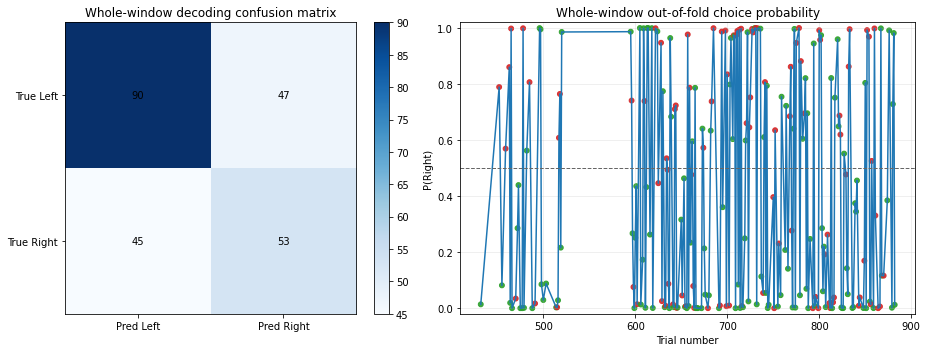

In [29]:
if X is None or y is None or trial_num_vector is None:
    print("Whole-window feature matrix is not ready yet.")
else:
    result = run_whole_window_decoder(X, y, group_vector)

    print(f"Whole-window splitter:   {result['split_name']}")
    print(f"Accuracy:               {result['accuracy']:.4f}")
    print(f"Balanced accuracy:      {result['balanced_accuracy']:.4f}")
    print("Confusion matrix [Left, Right]:")
    print(result["confusion_matrix"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cm = result["confusion_matrix"]
    im = axes[0].imshow(cm, cmap="Blues")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Pred Left", "Pred Right"])
    axes[0].set_yticklabels(["True Left", "True Right"])
    axes[0].set_title("Whole-window decoding confusion matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    sort_idx = np.argsort(trial_num_vector)
    sorted_trials = trial_num_vector[sort_idx]
    sorted_prob = result["prob"][sort_idx]
    sorted_true = y[sort_idx]
    axes[1].plot(sorted_trials, sorted_prob, color="#1f77b4", lw=1.5)
    axes[1].scatter(
        sorted_trials,
        sorted_prob,
        c=np.where(sorted_true == 1, "#d62728", "#2ca02c"),
        s=24,
        alpha=0.9,
    )
    axes[1].axhline(0.5, color="0.4", ls="--", lw=1.0)
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].set_xlabel("Trial number")
    axes[1].set_ylabel("P(Right)")
    axes[1].set_title("Whole-window out-of-fold choice probability")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


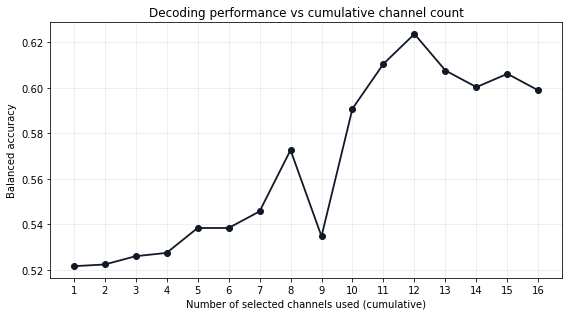

Cumulative channel order:
  1: [0]
  2: [0, 1]
  3: [0, 1, 2]
  4: [0, 1, 2, 3]
  5: [0, 1, 2, 3, 4]
  6: [0, 1, 2, 3, 4, 5]
  7: [0, 1, 2, 3, 4, 5, 6]
  8: [0, 1, 2, 3, 4, 5, 6, 7]
  9: [0, 1, 2, 3, 4, 5, 6, 7, 8]
  10: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  11: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  12: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
  13: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  14: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
  15: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  16: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [30]:
if band_dataset is None:
    print("Progressive channel decoding is not ready yet because band_dataset is unavailable.")
else:
    n_channels = len(SELECTED_LFP_CHANNELS)
    channel_counts = []
    perf_values = []

    for k in range(1, n_channels + 1):
        feature_blocks = []
        for band_name, _ in LFP_BANDS:
            tensor = band_dataset[band_name]["feature_tensors"][:, :k, :]
            feature_blocks.append(tensor.reshape(tensor.shape[0], -1))
        X_k = np.hstack(feature_blocks)
        result_k = run_whole_window_decoder(X_k, decode_y, decode_groups)
        perf_k = result_k["balanced_accuracy"] if TIME_RESOLVED_METRIC == "balanced_accuracy" else result_k["accuracy"]
        channel_counts.append(k)
        perf_values.append(perf_k)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(channel_counts, perf_values, marker="o", lw=1.8, color="#111827")
    ax.set_xticks(channel_counts)
    ax.set_xlabel("Number of selected channels used (cumulative)")
    ax.set_ylabel("Balanced accuracy" if TIME_RESOLVED_METRIC == "balanced_accuracy" else "Accuracy")
    ax.set_title("Decoding performance vs cumulative channel count")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print("Cumulative channel order:")
    for k in channel_counts:
        print(f"  {k}: {SELECTED_LFP_CHANNELS[:k]}")


In [31]:
[0,1,2,3,4,5,6,7,9,10,11,14]

[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 14]

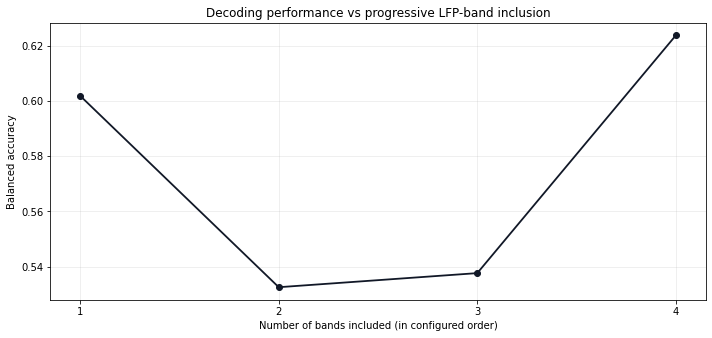

Selected channel count (best_k): 12
Selected channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Metric: balanced_accuracy
  Bands 1: theta -> balanced_accuracy=0.6018
  Bands 2: theta + beta -> balanced_accuracy=0.5325
  Bands 3: theta + beta + low_gamma -> balanced_accuracy=0.5376
  Bands 4: theta + beta + low_gamma + high_gamma -> balanced_accuracy=0.6237


In [32]:
if band_dataset is None:
    print("Band-order progressive decoding is not ready yet because band_dataset is unavailable.")
else:
    metric_label = "balanced_accuracy" if TIME_RESOLVED_METRIC == "balanced_accuracy" else "accuracy"
    n_channels = len(SELECTED_LFP_CHANNELS)

    # Step 1: pick the best channel count using all bands.
    channel_perf = []
    for k in range(1, n_channels + 1):
        blocks_k = []
        for band_name, _ in LFP_BANDS:
            tensor = band_dataset[band_name]["feature_tensors"][:, :k, :]
            blocks_k.append(tensor.reshape(tensor.shape[0], -1))
        X_k = np.hstack(blocks_k)
        result_k = run_whole_window_decoder(X_k, decode_y, decode_groups)
        perf_k = result_k["balanced_accuracy"] if TIME_RESOLVED_METRIC == "balanced_accuracy" else result_k["accuracy"]
        channel_perf.append(perf_k)

    best_k_idx = int(np.nanargmax(channel_perf))
    best_k = best_k_idx + 1

    # Step 2: progressively add bands in USER_CONFIG order (theta -> ... -> all).
    band_counts = []
    band_perf = []
    band_labels = []
    for b in range(1, len(LFP_BANDS) + 1):
        blocks_b = []
        used_band_names = [name for name, _ in LFP_BANDS[:b]]
        for band_name in used_band_names:
            tensor = band_dataset[band_name]["feature_tensors"][:, :best_k, :]
            blocks_b.append(tensor.reshape(tensor.shape[0], -1))
        X_b = np.hstack(blocks_b)
        result_b = run_whole_window_decoder(X_b, decode_y, decode_groups)
        perf_b = result_b["balanced_accuracy"] if TIME_RESOLVED_METRIC == "balanced_accuracy" else result_b["accuracy"]
        band_counts.append(b)
        band_perf.append(perf_b)
        band_labels.append(" + ".join(used_band_names))

    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(band_counts, band_perf, marker="o", lw=1.8, color="#111827")
    ax.set_xticks(band_counts)
    ax.set_xlabel("Number of bands included (in configured order)")
    ax.set_ylabel("Balanced accuracy" if TIME_RESOLVED_METRIC == "balanced_accuracy" else "Accuracy")
    ax.set_title("Decoding performance vs progressive LFP-band inclusion")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"Selected channel count (best_k): {best_k}")
    print(f"Selected channels: {SELECTED_LFP_CHANNELS[:best_k]}")
    print(f"Metric: {metric_label}")
    for b, label, perf in zip(band_counts, band_labels, band_perf):
        print(f"  Bands {b}: {label} -> {metric_label}={perf:.4f}")


In [33]:
channel_perf

[0.5215626396544019,
 0.5223074631312379,
 0.5259570981677343,
 0.5274095039475645,
 0.5383584090570535,
 0.5383584090570535,
 0.5456576791300461,
 0.5726202889915091,
 0.5347087740205572,
 0.5908684641739907,
 0.6105690451363027,
 0.6236779383286162,
 0.6076269924028005,
 0.6003277223298078,
 0.6061745866229704,
 0.5988753165499776]

## ESA Choice Decoding Aligned To First Choice Action

这部分直接使用 H5 中导出的 `esa_v` 模态，而不是 `raster_v`。

关键约定：
- 源信号：16 通道 `esa_v`，采样率约 1 kHz
- 当前 H5 中 ESA 的有效信息按现有导出理解是到约 150 Hz，而不是重新从 30 kHz broadband 现算出来的 12 Hz envelope
- 对齐事件：`tevent_list` 中 choice 侧第一次 lick，左为 `EventID == 8`，右为 `EventID == 10`
- 固定窗 baseline：默认 `[-250, 0] ms`，并按 `esa_baseline_bin_ms` 分箱
- 时间动态：窗宽 `esa_sliding_window_ms`、步长 `esa_sliding_step_ms`，都由 `USER_CONFIG` 直接控制
- 基线漂移控制：新增 `esa_baseline_reference_window_ms` + `esa_baseline_correction_mode`，默认对每个 trial / 通道做 pre-choice baseline subtraction
- 平滑：新增 `esa_pre_smoothing_ms`，可选地先对 ESA trace 做时间平滑，再进解码
- 模型：`StandardScaler + LogisticRegression(L2, class_weight="balanced")`
- 指标：balanced accuracy 与 AUC，并使用 label shuffle 构建 null distribution

如果后面你要严格复现“`300 Hz HPF -> abs -> 12 Hz LPF -> 1 kHz`”那条 ESA envelope 流程，需要从 raw broadband 重新生成；本 notebook 这里先分析当前 H5 已保存的 ESA 通道。



In [34]:
import json
from sklearn.metrics import roc_auc_score


def safe_binary_auc(y_true, y_score):
    try:
        return float(roc_auc_score(y_true, y_score))
    except ValueError:
        return float("nan")


def normalize_esa_mouse_cfg(cfg):
    trial_txt_path = as_path(cfg.get("trial_txt_path", TRIAL_TXT_PATH))
    return {
        "mouse": str(cfg.get("mouse") or cfg.get("mouse_id") or trial_txt_path.parent.name),
        "protocol": int(cfg.get("protocol", PROTOCOL_OF_INTEREST)),
        "trial_txt_path": trial_txt_path,
        "h5_path": as_path(cfg.get("h5_path", H5_PATH)),
    }


ESA_CONFIG = {
    "channels": sorted({int(ch) for ch in USER_CONFIG.get("esa_channels", list(range(16)))}),
    "baseline_window_ms": tuple(USER_CONFIG.get("esa_baseline_window_ms", [-250.0, 0.0])),
    "baseline_bin_ms": float(USER_CONFIG.get("esa_baseline_bin_ms", 25.0)),
    "sliding_range_ms": tuple(USER_CONFIG.get("esa_sliding_range_ms", [-250.0, 0.0])),
    "sliding_window_ms": float(USER_CONFIG.get("esa_sliding_window_ms", 100.0)),
    "sliding_step_ms": float(USER_CONFIG.get("esa_sliding_step_ms", 20.0)),
    "pre_smoothing_ms": float(USER_CONFIG.get("esa_pre_smoothing_ms", 0.0)),
    "baseline_reference_window_ms": tuple(USER_CONFIG.get("esa_baseline_reference_window_ms", [-500.0, -250.0])),
    "baseline_correction_mode": str(USER_CONFIG.get("esa_baseline_correction_mode", "subtract_mean")).lower(),
    "cv_splits": int(USER_CONFIG.get("esa_cv_splits", 5)),
    "null_shuffles": int(USER_CONFIG.get("esa_null_shuffles", 200)),
    "random_state": int(USER_CONFIG.get("esa_random_state", 42)),
    "left_choice_event_id": int(USER_CONFIG.get("esa_left_choice_event_id", 8)),
    "right_choice_event_id": int(USER_CONFIG.get("esa_right_choice_event_id", 10)),
    "expected_fs_hz": float(USER_CONFIG.get("esa_expected_fs_hz", 1000.0)),
    "effective_bandwidth_hz": float(USER_CONFIG.get("esa_effective_bandwidth_hz", 150.0)),
    "trialstart_range_ms": tuple(USER_CONFIG.get("esa_trialstart_range_ms", [-500.0, 0.0])),
    "trialstart_window_ms": float(USER_CONFIG.get("esa_trialstart_window_ms", 20.0)),
    "trialstart_step_ms": float(USER_CONFIG.get("esa_trialstart_step_ms", 20.0)),
}

baseline_span_ms = ESA_CONFIG["baseline_window_ms"][1] - ESA_CONFIG["baseline_window_ms"][0]
if abs(round(baseline_span_ms / ESA_CONFIG["baseline_bin_ms"]) - (baseline_span_ms / ESA_CONFIG["baseline_bin_ms"])) > 1e-9:
    raise ValueError("ESA baseline window must be divisible by esa_baseline_bin_ms.")
if ESA_CONFIG["sliding_window_ms"] <= 0 or ESA_CONFIG["sliding_step_ms"] <= 0:
    raise ValueError("ESA sliding_window_ms and esa_sliding_step_ms must be > 0.")
if ESA_CONFIG["sliding_window_ms"] > (ESA_CONFIG["sliding_range_ms"][1] - ESA_CONFIG["sliding_range_ms"][0]):
    raise ValueError("ESA sliding_window_ms must fit inside esa_sliding_range_ms.")
if ESA_CONFIG["baseline_correction_mode"] not in {"none", "subtract_mean", "zscore"}:
    raise ValueError("esa_baseline_correction_mode must be one of: 'none', 'subtract_mean', 'zscore'.")
if ESA_CONFIG["trialstart_window_ms"] <= 0 or ESA_CONFIG["trialstart_step_ms"] <= 0:
    raise ValueError("esa_trialstart_window_ms and esa_trialstart_step_ms must be > 0.")
if ESA_CONFIG["trialstart_step_ms"] + 1e-9 < ESA_CONFIG["trialstart_window_ms"]:
    raise ValueError(
        "For the TrialStart-aligned control plot, esa_trialstart_step_ms must be >= esa_trialstart_window_ms to avoid overlap leakage between neighboring time bins."
    )

mouse_cfgs = USER_CONFIG.get("esa_mouse_datasets")
if not mouse_cfgs:
    mouse_cfgs = [{
        "mouse": USER_CONFIG.get("mouse_label", TRIAL_TXT_PATH.parent.name),
        "protocol": PROTOCOL_OF_INTEREST,
        "trial_txt_path": TRIAL_TXT_PATH,
        "h5_path": H5_PATH,
    }]
ESA_CONFIG["mouse_datasets"] = [normalize_esa_mouse_cfg(cfg) for cfg in mouse_cfgs]


def load_tevent_list_from_group(grp):
    raw = grp.attrs.get("tevent_list", "[]")
    if isinstance(raw, bytes):
        raw = raw.decode("utf-8")
    return json.loads(raw)


def get_first_choice_action_ms(tevent_list, trial_start_ts, choice, left_event_id, right_event_id):
    target_event_id = left_event_id if int(choice) == 1 else right_event_id
    rel_times = [
        float(ev_ts) - float(trial_start_ts)
        for ev_id, ev_ts in tevent_list
        if int(ev_id) == int(target_event_id)
    ]
    if not rel_times:
        return None
    return float(min(rel_times))


def window_is_fully_covered(time_ms, window_ms):
    time_ms = np.asarray(time_ms, dtype=float)
    if time_ms.size < 2:
        return False
    dt_ms = float(np.median(np.diff(time_ms)))
    return bool(time_ms[0] <= window_ms[0] + 1e-6 and time_ms[-1] >= window_ms[1] - dt_ms - 1e-6)


def build_esa_time_bins(window_ms, bin_ms):
    t0_ms, t1_ms = window_ms
    n_bins = int(round((t1_ms - t0_ms) / bin_ms))
    return np.linspace(t0_ms, t1_ms, n_bins + 1)


def smooth_esa_matrix(time_ms, values, smoothing_ms):
    values = np.asarray(values, dtype=float)
    if smoothing_ms <= 0:
        return np.array(values, copy=True)
    if time_ms.size < 3:
        return np.array(values, copy=True)

    dt_ms = float(np.median(np.diff(time_ms)))
    win_samples = int(round(smoothing_ms / dt_ms))
    if win_samples <= 1:
        return np.array(values, copy=True)
    if win_samples % 2 == 0:
        win_samples += 1

    kernel = np.ones(win_samples, dtype=float) / float(win_samples)
    return np.vstack([np.convolve(ch, kernel, mode="same") for ch in values])


def baseline_correct_esa(time_ms, values, baseline_window_ms, mode):
    values = np.asarray(values, dtype=float)
    if mode == "none":
        return np.array(values, copy=True)

    baseline_mask = (time_ms >= baseline_window_ms[0]) & (time_ms < baseline_window_ms[1])
    if not np.any(baseline_mask):
        raise ValueError(
            f"ESA baseline reference window {baseline_window_ms} is not covered by the aligned trace."
        )

    baseline_vals = values[:, baseline_mask]
    baseline_mean = np.mean(baseline_vals, axis=1, keepdims=True)

    if mode == "subtract_mean":
        return values - baseline_mean

    baseline_std = np.std(baseline_vals, axis=1, keepdims=True)
    baseline_std = np.where(baseline_std < 1e-6, 1.0, baseline_std)
    return (values - baseline_mean) / baseline_std


def preprocess_esa_trial(time_ms, values, cfg):
    time_ms = np.asarray(time_ms, dtype=float)
    processed = smooth_esa_matrix(time_ms, values, cfg["pre_smoothing_ms"])
    processed = baseline_correct_esa(
        time_ms,
        processed,
        cfg["baseline_reference_window_ms"],
        cfg["baseline_correction_mode"],
    )
    return processed


def extract_esa_binned_means(time_ms, values, window_ms, bin_ms):
    time_win, values_win = slice_window(time_ms, values, window_ms)
    if time_win.size == 0:
        raise ValueError(f"ESA window {window_ms} is empty after alignment.")

    bins_ms = build_esa_time_bins(window_ms, bin_ms)
    feats = []
    for ch_idx in range(values_win.shape[0]):
        for start_ms, stop_ms in zip(bins_ms[:-1], bins_ms[1:]):
            mask = (time_win >= start_ms) & (time_win < stop_ms)
            if not np.any(mask):
                feats.append(0.0)
            else:
                feats.append(float(np.mean(values_win[ch_idx, mask])))
    return sanitize_features(np.asarray(feats, dtype=float))


def build_esa_cv_splits(y, groups, n_splits, random_state):
    y = np.asarray(y, dtype=int)
    groups = np.asarray(groups)
    class_counts = np.bincount(y, minlength=2)
    if np.min(class_counts) < 2:
        raise ValueError("Need at least two trials in each class for ESA decoding.")

    unique_groups = np.unique(groups)
    if unique_groups.size >= 3:
        splitter = GroupKFold(n_splits=min(n_splits, unique_groups.size))
        splits = list(splitter.split(np.zeros_like(y), y, groups=groups))
        split_name = f"GroupKFold(n_splits={splitter.n_splits})"
    else:
        splitter = StratifiedKFold(
            n_splits=int(min(n_splits, np.min(class_counts))),
            shuffle=True,
            random_state=random_state,
        )
        splits = list(splitter.split(np.zeros_like(y), y))
        split_name = f"StratifiedKFold(n_splits={splitter.n_splits})"
    return splits, split_name


def run_esa_decoder(X, y, groups, n_splits, random_state):
    y = np.asarray(y, dtype=int)
    X = sanitize_features(X)
    splits, split_name = build_esa_cv_splits(y, groups, n_splits, random_state)
    pred = np.full(y.shape, np.nan)
    prob = np.full(y.shape, np.nan)

    for train_idx, test_idx in splits:
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=5000,
                solver="lbfgs",
                class_weight="balanced",
                random_state=random_state,
            ),
        )
        clf.fit(X[train_idx], y[train_idx])
        pred[test_idx] = clf.predict(X[test_idx])
        prob[test_idx] = clf.predict_proba(X[test_idx])[:, 1]

    pred_int = pred.astype(int)
    return {
        "split_name": split_name,
        "pred": pred_int,
        "prob": prob,
        "balanced_accuracy": float(balanced_accuracy_score(y, pred_int)),
        "auc": safe_binary_auc(y, prob),
        "confusion_matrix": confusion_matrix(y, pred_int),
    }


def run_label_shuffle_null(X, y, groups, n_splits, n_shuffles, random_state):
    rng = np.random.default_rng(random_state)
    bal_acc = []
    auc_vals = []
    for shuffle_idx in range(n_shuffles):
        y_shuffle = rng.permutation(y)
        result = run_esa_decoder(X, y_shuffle, groups, n_splits, random_state + shuffle_idx + 1)
        bal_acc.append(result["balanced_accuracy"])
        auc_vals.append(result["auc"])
    return {
        "balanced_accuracy": np.asarray(bal_acc, dtype=float),
        "auc": np.asarray(auc_vals, dtype=float),
    }


def empirical_p_value(actual_value, null_values):
    null_values = np.asarray(null_values, dtype=float)
    valid = np.isfinite(null_values)
    if not np.any(valid):
        return float("nan")
    return float((1.0 + np.sum(null_values[valid] >= actual_value)) / (1.0 + np.sum(valid)))


def build_feature_matrix_from_trials(trials, window_ms, bin_ms, time_key="aligned_t_ms", value_key="esa_v"):
    return np.vstack([
        extract_esa_binned_means(trial[time_key], trial[value_key], window_ms, bin_ms)
        for trial in trials
    ])


def infer_protocol6_sample_timing_from_ino(repo_root):
    ino_path = Path(repo_root) / "Protocol" / "DBRuleSwitch" / "DBRuleSwitch.ino"
    info = {
        "ino_path": ino_path,
        "trialstart_state_ms": float("nan"),
        "precue_delay_ms": float("nan"),
        "sample_delay_ms": 250.0,
        "sample_onset_ms": float("nan"),
        "sample_cue_state_ms": float("nan"),
    }
    if not ino_path.exists():
        return info

    text = ino_path.read_text(encoding="utf-8")
    trialstart_match = re.search(r"const int TrialStartStateDurationMs\s*=\s*(\d+);", text)
    precue_match = re.search(r"S\.PreCueDelayPeriod\s*=\s*(\d+);", text)

    if trialstart_match:
        info["trialstart_state_ms"] = float(trialstart_match.group(1))
    if precue_match:
        info["precue_delay_ms"] = float(precue_match.group(1))

    if np.isfinite(info["trialstart_state_ms"]) and np.isfinite(info["precue_delay_ms"]):
        info["sample_onset_ms"] = info["trialstart_state_ms"] + info["precue_delay_ms"]
        info["sample_cue_state_ms"] = info["sample_onset_ms"] + info["sample_delay_ms"]
    return info


PROTOCOL6_SAMPLE_TIMING = infer_protocol6_sample_timing_from_ino(REPO_ROOT)


def build_sliding_windows(range_ms, win_ms, step_ms):
    starts = np.arange(range_ms[0], range_ms[1] - win_ms + step_ms * 0.5, step_ms)
    stops = starts + win_ms
    centers = starts + win_ms / 2.0
    return starts, stops, centers


def run_metric_curve(feature_blocks, y, groups, n_splits, random_state):
    bal_curve = []
    auc_curve = []
    for block in feature_blocks:
        result = run_esa_decoder(block, y, groups, n_splits, random_state)
        bal_curve.append(result["balanced_accuracy"])
        auc_curve.append(result["auc"])
    return {
        "balanced_accuracy": np.asarray(bal_curve, dtype=float),
        "auc": np.asarray(auc_curve, dtype=float),
    }


def run_metric_curve_shuffle_null(feature_blocks, y, groups, n_splits, n_shuffles, random_state):
    rng = np.random.default_rng(random_state)
    bal_curves = []
    auc_curves = []
    for shuffle_idx in range(n_shuffles):
        y_shuffle = rng.permutation(y)
        curve = run_metric_curve(feature_blocks, y_shuffle, groups, n_splits, random_state + shuffle_idx + 1)
        bal_curves.append(curve["balanced_accuracy"])
        auc_curves.append(curve["auc"])
    return {
        "balanced_accuracy": np.asarray(bal_curves, dtype=float),
        "auc": np.asarray(auc_curves, dtype=float),
    }


print("ESA source note: using H5-exported `esa_v` as the analog ESA stream, not `raster_v`.")
print(f"ESA channels:                 {ESA_CONFIG['channels']}")
print(f"ESA fixed window (ms):        {ESA_CONFIG['baseline_window_ms']}")
print(f"ESA bin size (ms):            {ESA_CONFIG['baseline_bin_ms']}")
print(f"ESA sliding range (ms):       {ESA_CONFIG['sliding_range_ms']}")
print(f"ESA sliding window (ms):      {ESA_CONFIG['sliding_window_ms']}")
print(f"ESA sliding step (ms):        {ESA_CONFIG['sliding_step_ms']}")
print(f"ESA pre-smoothing (ms):       {ESA_CONFIG['pre_smoothing_ms']}")
print(f"ESA baseline ref window (ms): {ESA_CONFIG['baseline_reference_window_ms']}")
print(f"ESA baseline mode:            {ESA_CONFIG['baseline_correction_mode']}")
print(f"ESA CV splits:                {ESA_CONFIG['cv_splits']}")
print(f"ESA label shuffles:           {ESA_CONFIG['null_shuffles']}")
print(f"ESA expected fs (Hz):         {ESA_CONFIG['expected_fs_hz']}")
print(f"ESA assumed bandwidth (Hz):   <= {ESA_CONFIG['effective_bandwidth_hz']}")
print(f"ESA TrialStart range (ms):    {ESA_CONFIG['trialstart_range_ms']}")
print(f"ESA TrialStart window (ms):   {ESA_CONFIG['trialstart_window_ms']}")
print(f"ESA TrialStart step (ms):     {ESA_CONFIG['trialstart_step_ms']}")
print(f"ESA mice configured:          {[cfg['mouse'] for cfg in ESA_CONFIG['mouse_datasets']]}")
if np.isfinite(PROTOCOL6_SAMPLE_TIMING['sample_onset_ms']):
    print(
        f"Protocol 6 sample onset from TrialStart: +{PROTOCOL6_SAMPLE_TIMING['sample_onset_ms']:.1f} ms "
        f"(TrialStart {PROTOCOL6_SAMPLE_TIMING['trialstart_state_ms']:.1f} ms + PreCueDelay {PROTOCOL6_SAMPLE_TIMING['precue_delay_ms']:.1f} ms; SampleOutput starts in SampleDelay)."
    )


ESA source note: using H5-exported `esa_v` as the analog ESA stream, not `raster_v`.
ESA channels:                 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
ESA fixed window (ms):        (-250.0, 0.0)
ESA bin size (ms):            25.0
ESA sliding range (ms):       (-250.0, 0.0)
ESA sliding window (ms):      100.0
ESA sliding step (ms):        20.0
ESA pre-smoothing (ms):       0.0
ESA baseline ref window (ms): (-500.0, -250.0)
ESA baseline mode:            subtract_mean
ESA CV splits:                5
ESA label shuffles:           200
ESA expected fs (Hz):         1000.0
ESA assumed bandwidth (Hz):   <= 150.0
ESA TrialStart range (ms):    (-500.0, 0.0)
ESA TrialStart window (ms):   20.0
ESA TrialStart step (ms):     20.0
ESA mice configured:          ['BW08']
Protocol 6 sample onset from TrialStart: +62.0 ms (TrialStart 18.0 ms + PreCueDelay 44.0 ms; SampleOutput starts in SampleDelay).


In [35]:
esa_mouse_trials = {}
esa_loader_summary = []

required_alignment_window_ms = (
    min(
        ESA_CONFIG["baseline_reference_window_ms"][0],
        ESA_CONFIG["baseline_window_ms"][0],
        ESA_CONFIG["sliding_range_ms"][0],
    ),
    max(
        ESA_CONFIG["baseline_reference_window_ms"][1],
        ESA_CONFIG["baseline_window_ms"][1],
        ESA_CONFIG["sliding_range_ms"][1],
    ),
)

for mouse_cfg in ESA_CONFIG["mouse_datasets"]:
    mouse_name = mouse_cfg["mouse"]
    trial_txt_path = mouse_cfg["trial_txt_path"]
    h5_path = mouse_cfg["h5_path"]
    protocol_id = mouse_cfg["protocol"]

    if trial_txt_path is None or not trial_txt_path.exists():
        print(f"[{mouse_name}] Trial.txt not found: {trial_txt_path}")
        continue
    if h5_path is None or not h5_path.exists():
        print(f"[{mouse_name}] H5 not found: {h5_path}")
        continue

    trial_rows_mouse = attach_trailing_perf50(
        parse_trial_txt(trial_txt_path),
        protocol=protocol_id,
        window=ROLLING_WINDOW_VALID_TRIALS,
    )

    if INCLUDE_ERROR_TRIALS_IN_DECODING:
        analysis_rows_mouse = [
            row for row in trial_rows_mouse
            if row["protocol"] == protocol_id and row["choice"] in (1, 2) and row["passes_perf50"]
        ]
    else:
        analysis_rows_mouse = [
            row for row in trial_rows_mouse
            if row["protocol"] == protocol_id
            and row["outcome"] == 1
            and row["trial_type"] in (1, 2)
            and row["passes_perf50"]
        ]

    h5_index_mouse = build_h5_index(h5_path)
    h5_by_trial_mouse = {}
    for item in h5_index_mouse:
        h5_by_trial_mouse.setdefault(item["trial_num"], []).append(item)

    matched_trials = []
    missing_in_h5 = 0
    missing_esa = 0
    missing_choice_action = 0
    short_window = 0
    fs_values = []

    with h5py.File(h5_path, "r") as h5_file:
        for row in analysis_rows_mouse:
            candidates = h5_by_trial_mouse.get(row["trial_num"], [])
            if not candidates:
                missing_in_h5 += 1
                continue

            h5_rec = candidates[0]
            grp = h5_file[h5_rec["trial_key"]]
            if "esa_v" not in grp:
                missing_esa += 1
                continue

            tevent_list = load_tevent_list_from_group(grp)
            trial_start_ts = float(grp.attrs["trial_start_ts"])
            first_choice_action_ms = get_first_choice_action_ms(
                tevent_list,
                trial_start_ts,
                row["choice"],
                ESA_CONFIG["left_choice_event_id"],
                ESA_CONFIG["right_choice_event_id"],
            )
            if first_choice_action_ms is None:
                missing_choice_action += 1
                continue

            esa_t = np.array(grp["esa_t"]) if "esa_t" in grp else np.array(grp["lfp_t"])
            trialstart_t_ms = np.asarray(esa_t, dtype=float)
            esa_v = np.array(grp["esa_v"], dtype=float)[ESA_CONFIG["channels"]]
            aligned_t_ms = trialstart_t_ms - float(first_choice_action_ms)

            if not window_is_fully_covered(aligned_t_ms, required_alignment_window_ms):
                short_window += 1
                continue
            if not window_is_fully_covered(trialstart_t_ms, ESA_CONFIG["trialstart_range_ms"]):
                short_window += 1
                continue

            esa_v_action_aligned = preprocess_esa_trial(aligned_t_ms, esa_v, ESA_CONFIG)
            esa_v_trialstart = preprocess_esa_trial(trialstart_t_ms, esa_v, ESA_CONFIG)

            matched_trials.append({
                "mouse": mouse_name,
                "trial_num": row["trial_num"],
                "session": h5_rec["session"],
                "choice": row["choice"],
                "aligned_t_ms": aligned_t_ms,
                "trialstart_t_ms": trialstart_t_ms,
                "esa_v_raw": esa_v,
                "esa_v": esa_v_action_aligned,
                "esa_v_trialstart": esa_v_trialstart,
                "first_choice_action_ms": float(first_choice_action_ms),
            })
            fs_values.append(infer_fs(np.asarray(esa_t, dtype=float)))

    esa_mouse_trials[mouse_name] = matched_trials
    esa_loader_summary.append({
        "mouse": mouse_name,
        "protocol": protocol_id,
        "candidate_trials": len(analysis_rows_mouse),
        "matched_trials": len(matched_trials),
        "missing_in_h5": missing_in_h5,
        "missing_esa": missing_esa,
        "missing_choice_action": missing_choice_action,
        "short_window": short_window,
        "median_fs_hz": float(np.nanmedian(fs_values)) if fs_values else float("nan"),
    })

if not esa_loader_summary:
    print("ESA loader did not find any usable mouse dataset yet.")
else:
    for row in esa_loader_summary:
        print(
            f"[{row['mouse']}] protocol={row['protocol']} | candidate={row['candidate_trials']} | "
            f"matched={row['matched_trials']} | missing_h5={row['missing_in_h5']} | "
            f"missing_esa={row['missing_esa']} | missing_choice_action={row['missing_choice_action']} | "
            f"short_window={row['short_window']} | median_fs={row['median_fs_hz']:.3f} Hz"
        )

    detected_fs = np.array([row["median_fs_hz"] for row in esa_loader_summary if np.isfinite(row["median_fs_hz"])], dtype=float)
    if detected_fs.size:
        print(f"Detected ESA sampling rate summary (Hz): min={detected_fs.min():.3f}, median={np.median(detected_fs):.3f}, max={detected_fs.max():.3f}")
        if np.any(np.abs(detected_fs - ESA_CONFIG['expected_fs_hz']) > 5.0):
            print("Warning: detected ESA sampling rate is not tightly centered on the configured 1 kHz assumption.")


[BW08] protocol=6 | candidate=235 | matched=223 | missing_h5=0 | missing_esa=0 | missing_choice_action=0 | short_window=12 | median_fs=1000.000 Hz
Detected ESA sampling rate summary (Hz): min=1000.000, median=1000.000, max=1000.000


ESA fixed-window decoding summary:
  BW08: n=223 | Left=131 | Right=92 | splitter=GroupKFold(n_splits=5) | bal_acc=0.7203 (null95=0.5646, p=0.0050) | auc=0.7736 (null95=0.5808, p=0.0050)
[[99 32]
 [29 63]]


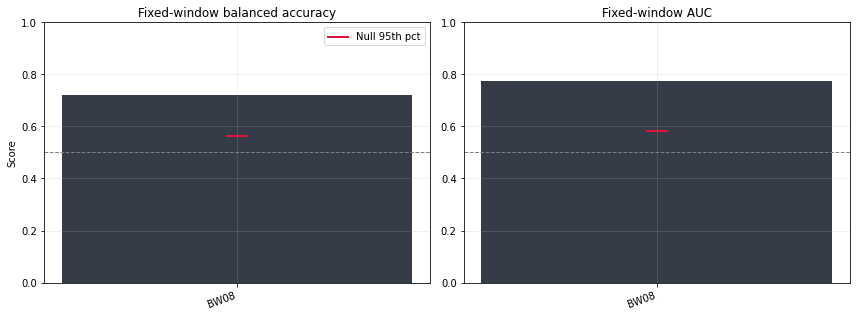

Across-mouse fixed-window summary:
  mean balanced accuracy = 0.7203 | null mean 95th pct = 0.5646 | empirical p = 0.0050
  mean AUC = 0.7736 | null mean 95th pct = 0.5808 | empirical p = 0.0050


d:\anaconda\envs\Habits\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


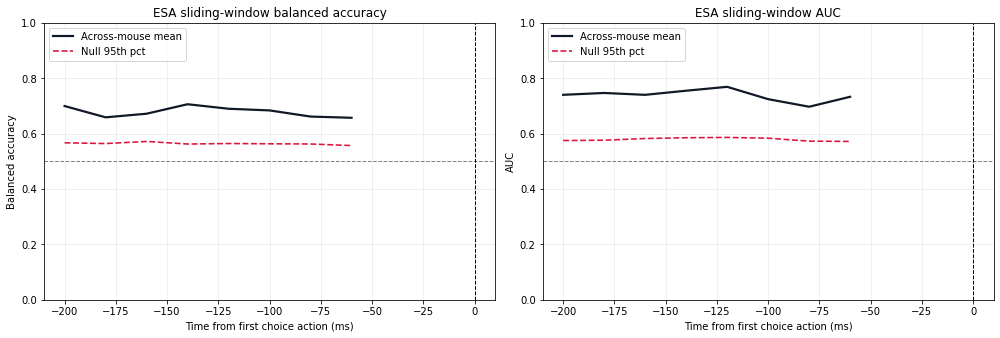

Across-mouse sliding-window summary:
  First balanced-accuracy bin above null95: -200.0 ms
  First AUC bin above null95: -200.0 ms


d:\anaconda\envs\Habits\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


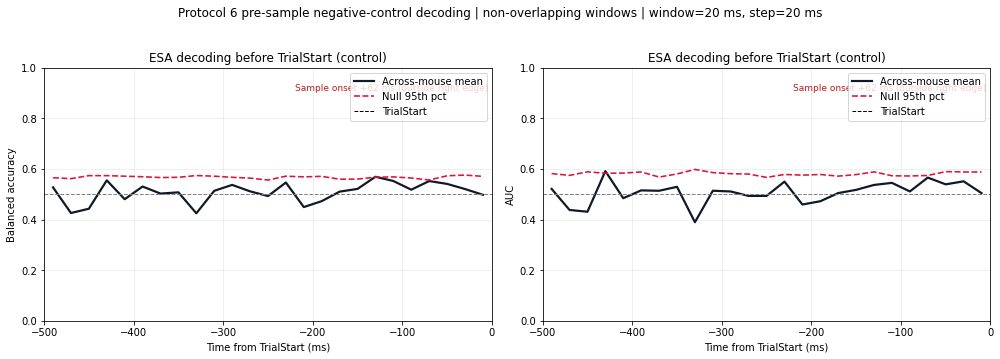

TrialStart-aligned pre-sample control summary:
  Protocol 6 sample onset = +62.0 ms from TrialStart
  This requested window ends at TrialStart (0 ms), so it is entirely before sample onset for protocol 6 and should behave as a negative control.
  First balanced-accuracy bin above null95: -130.0 ms
  First AUC bin above null95: -430.0 ms


In [36]:
esa_fixed_results = {}
esa_time_resolved_results = {}

if not esa_mouse_trials or not any(esa_mouse_trials.values()):
    print("ESA decoding is not ready yet because no aligned ESA trials were loaded.")
else:
    starts_ms, stops_ms, centers_ms = build_sliding_windows(
        ESA_CONFIG["sliding_range_ms"],
        ESA_CONFIG["sliding_window_ms"],
        ESA_CONFIG["sliding_step_ms"],
    )

    for mouse_name, trials in esa_mouse_trials.items():
        if not trials:
            continue

        y_mouse = np.asarray([1 if trial["choice"] == 2 else 0 for trial in trials], dtype=int)
        groups_mouse = np.asarray([trial["session"] for trial in trials])

        X_fixed = build_feature_matrix_from_trials(
            trials,
            ESA_CONFIG["baseline_window_ms"],
            ESA_CONFIG["baseline_bin_ms"],
        )
        fixed_result = run_esa_decoder(
            X_fixed,
            y_mouse,
            groups_mouse,
            ESA_CONFIG["cv_splits"],
            ESA_CONFIG["random_state"],
        )
        fixed_null = run_label_shuffle_null(
            X_fixed,
            y_mouse,
            groups_mouse,
            ESA_CONFIG["cv_splits"],
            ESA_CONFIG["null_shuffles"],
            ESA_CONFIG["random_state"],
        )
        fixed_result["null"] = fixed_null
        fixed_result["n_trials"] = int(len(trials))
        fixed_result["class_counts"] = {
            "Left": int(np.sum(y_mouse == 0)),
            "Right": int(np.sum(y_mouse == 1)),
        }
        fixed_result["p_balanced_accuracy"] = empirical_p_value(
            fixed_result["balanced_accuracy"],
            fixed_null["balanced_accuracy"],
        )
        fixed_result["p_auc"] = empirical_p_value(fixed_result["auc"], fixed_null["auc"])
        esa_fixed_results[mouse_name] = fixed_result

        feature_blocks = [
            build_feature_matrix_from_trials(trials, (start_ms, stop_ms), ESA_CONFIG["baseline_bin_ms"])
            for start_ms, stop_ms in zip(starts_ms, stops_ms)
        ]
        curve_result = run_metric_curve(
            feature_blocks,
            y_mouse,
            groups_mouse,
            ESA_CONFIG["cv_splits"],
            ESA_CONFIG["random_state"],
        )
        curve_null = run_metric_curve_shuffle_null(
            feature_blocks,
            y_mouse,
            groups_mouse,
            ESA_CONFIG["cv_splits"],
            ESA_CONFIG["null_shuffles"],
            ESA_CONFIG["random_state"],
        )
        esa_time_resolved_results[mouse_name] = {
            "time_ms": centers_ms,
            "balanced_accuracy": curve_result["balanced_accuracy"],
            "auc": curve_result["auc"],
            "null_balanced_accuracy": curve_null["balanced_accuracy"],
            "null_auc": curve_null["auc"],
            "n_trials": int(len(trials)),
        }

    if not esa_fixed_results:
        print("ESA decoding could not run because no mouse had enough left/right trials after filtering.")
    else:
        print("ESA fixed-window decoding summary:")
        for mouse_name, result in esa_fixed_results.items():
            bal_null_95 = float(np.nanpercentile(result["null"]["balanced_accuracy"], 95))
            auc_null_95 = float(np.nanpercentile(result["null"]["auc"], 95))
            print(
                f"  {mouse_name}: n={result['n_trials']} | Left={result['class_counts']['Left']} | Right={result['class_counts']['Right']} | "
                f"splitter={result['split_name']} | bal_acc={result['balanced_accuracy']:.4f} (null95={bal_null_95:.4f}, p={result['p_balanced_accuracy']:.4f}) | "
                f"auc={result['auc']:.4f} (null95={auc_null_95:.4f}, p={result['p_auc']:.4f})"
            )
            print(result["confusion_matrix"])

        mouse_names = list(esa_fixed_results.keys())
        x_pos = np.arange(len(mouse_names))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
        for ax, metric_key, title in zip(
            axes,
            ["balanced_accuracy", "auc"],
            ["Fixed-window balanced accuracy", "Fixed-window AUC"],
        ):
            actual = np.asarray([esa_fixed_results[m][metric_key] for m in mouse_names], dtype=float)
            null95 = np.asarray([
                np.nanpercentile(esa_fixed_results[m]["null"][metric_key], 95)
                for m in mouse_names
            ], dtype=float)
            ax.bar(x_pos, actual, color="#111827", alpha=0.85)
            ax.scatter(x_pos, null95, color="crimson", marker="_", s=500, linewidths=2, label="Null 95th pct")
            ax.axhline(0.5, color="0.5", ls="--", lw=1.0)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(mouse_names, rotation=20, ha="right")
            ax.set_ylim(0.0, 1.0)
            ax.set_title(title)
            ax.grid(alpha=0.25)
        axes[0].set_ylabel("Score")
        axes[0].legend(loc="best")
        plt.tight_layout()
        plt.show()

        bal_actual = np.asarray([esa_fixed_results[m]["balanced_accuracy"] for m in mouse_names], dtype=float)
        auc_actual = np.asarray([esa_fixed_results[m]["auc"] for m in mouse_names], dtype=float)
        bal_null_mean = np.nanmean(np.vstack([esa_fixed_results[m]["null"]["balanced_accuracy"] for m in mouse_names]), axis=0)
        auc_null_mean = np.nanmean(np.vstack([esa_fixed_results[m]["null"]["auc"] for m in mouse_names]), axis=0)

        print("Across-mouse fixed-window summary:")
        print(
            f"  mean balanced accuracy = {np.nanmean(bal_actual):.4f} | null mean 95th pct = {np.nanpercentile(bal_null_mean, 95):.4f} | "
            f"empirical p = {empirical_p_value(np.nanmean(bal_actual), bal_null_mean):.4f}"
        )
        print(
            f"  mean AUC = {np.nanmean(auc_actual):.4f} | null mean 95th pct = {np.nanpercentile(auc_null_mean, 95):.4f} | "
            f"empirical p = {empirical_p_value(np.nanmean(auc_actual), auc_null_mean):.4f}"
        )

    if esa_time_resolved_results:
        mouse_names = list(esa_time_resolved_results.keys())
        time_ms = next(iter(esa_time_resolved_results.values()))["time_ms"]
        bal_matrix = np.vstack([esa_time_resolved_results[m]["balanced_accuracy"] for m in mouse_names])
        auc_matrix = np.vstack([esa_time_resolved_results[m]["auc"] for m in mouse_names])
        bal_null_mean = np.nanmean(np.stack([esa_time_resolved_results[m]["null_balanced_accuracy"] for m in mouse_names], axis=0), axis=0)
        auc_null_mean = np.nanmean(np.stack([esa_time_resolved_results[m]["null_auc"] for m in mouse_names], axis=0), axis=0)
        bal_null95 = np.nanpercentile(bal_null_mean, 95, axis=0)
        auc_null95 = np.nanpercentile(auc_null_mean, 95, axis=0)
        bal_mean = np.nanmean(bal_matrix, axis=0)
        auc_mean = np.nanmean(auc_matrix, axis=0)
        bal_sem = nansem(bal_matrix, axis=0)
        auc_sem = nansem(auc_matrix, axis=0)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
        for mouse_name in mouse_names:
            axes[0].plot(
                time_ms,
                esa_time_resolved_results[mouse_name]["balanced_accuracy"],
                color="0.75",
                lw=1.0,
                alpha=0.9,
            )
            axes[1].plot(
                time_ms,
                esa_time_resolved_results[mouse_name]["auc"],
                color="0.75",
                lw=1.0,
                alpha=0.9,
            )

        axes[0].plot(time_ms, bal_mean, color="#111827", lw=2.2, label="Across-mouse mean")
        axes[0].fill_between(time_ms, bal_mean - bal_sem, bal_mean + bal_sem, color="#111827", alpha=0.15)
        axes[0].plot(time_ms, bal_null95, color="crimson", lw=1.6, ls="--", label="Null 95th pct")
        axes[0].axhline(0.5, color="0.5", ls="--", lw=1.0)
        axes[0].axvline(0, color="black", ls="--", lw=1.0)
        axes[0].set_ylim(0.0, 1.0)
        axes[0].set_title("ESA sliding-window balanced accuracy")
        axes[0].set_ylabel("Balanced accuracy")
        axes[0].grid(alpha=0.25)
        axes[0].legend(loc="best")

        axes[1].plot(time_ms, auc_mean, color="#111827", lw=2.2, label="Across-mouse mean")
        axes[1].fill_between(time_ms, auc_mean - auc_sem, auc_mean + auc_sem, color="#111827", alpha=0.15)
        axes[1].plot(time_ms, auc_null95, color="crimson", lw=1.6, ls="--", label="Null 95th pct")
        axes[1].axhline(0.5, color="0.5", ls="--", lw=1.0)
        axes[1].axvline(0, color="black", ls="--", lw=1.0)
        axes[1].set_ylim(0.0, 1.0)
        axes[1].set_title("ESA sliding-window AUC")
        axes[1].set_ylabel("AUC")
        axes[1].grid(alpha=0.25)
        axes[1].legend(loc="best")

        for ax in axes:
            ax.set_xlabel("Time from first choice action (ms)")

        plt.tight_layout()
        plt.show()

        bal_sig_idx = np.where(bal_mean > bal_null95)[0]
        auc_sig_idx = np.where(auc_mean > auc_null95)[0]
        print("Across-mouse sliding-window summary:")
        print(
            "  First balanced-accuracy bin above null95:",
            "None" if bal_sig_idx.size == 0 else f"{time_ms[bal_sig_idx[0]]:.1f} ms",
        )
        print(
            "  First AUC bin above null95:",
            "None" if auc_sig_idx.size == 0 else f"{time_ms[auc_sig_idx[0]]:.1f} ms",
        )

trialstart_control_results = {}

if esa_mouse_trials and any(esa_mouse_trials.values()):
    ts_starts_ms, ts_stops_ms, ts_centers_ms = build_sliding_windows(
        ESA_CONFIG["trialstart_range_ms"],
        ESA_CONFIG["trialstart_window_ms"],
        ESA_CONFIG["trialstart_step_ms"],
    )

    for mouse_name, trials in esa_mouse_trials.items():
        if not trials:
            continue

        y_mouse = np.asarray([1 if trial["choice"] == 2 else 0 for trial in trials], dtype=int)
        groups_mouse = np.asarray([trial["session"] for trial in trials])

        feature_blocks = [
            build_feature_matrix_from_trials(
                trials,
                (start_ms, stop_ms),
                ESA_CONFIG["trialstart_window_ms"],
                time_key="trialstart_t_ms",
                value_key="esa_v_trialstart",
            )
            for start_ms, stop_ms in zip(ts_starts_ms, ts_stops_ms)
        ]

        curve_result = run_metric_curve(
            feature_blocks,
            y_mouse,
            groups_mouse,
            ESA_CONFIG["cv_splits"],
            ESA_CONFIG["random_state"],
        )
        curve_null = run_metric_curve_shuffle_null(
            feature_blocks,
            y_mouse,
            groups_mouse,
            ESA_CONFIG["cv_splits"],
            ESA_CONFIG["null_shuffles"],
            ESA_CONFIG["random_state"],
        )
        trialstart_control_results[mouse_name] = {
            "time_ms": ts_centers_ms,
            "balanced_accuracy": curve_result["balanced_accuracy"],
            "auc": curve_result["auc"],
            "null_balanced_accuracy": curve_null["balanced_accuracy"],
            "null_auc": curve_null["auc"],
            "n_trials": int(len(trials)),
        }

if trialstart_control_results:
    mouse_names = list(trialstart_control_results.keys())
    time_ms = next(iter(trialstart_control_results.values()))["time_ms"]
    bal_matrix = np.vstack([trialstart_control_results[m]["balanced_accuracy"] for m in mouse_names])
    auc_matrix = np.vstack([trialstart_control_results[m]["auc"] for m in mouse_names])
    bal_null_mean = np.nanmean(np.stack([trialstart_control_results[m]["null_balanced_accuracy"] for m in mouse_names], axis=0), axis=0)
    auc_null_mean = np.nanmean(np.stack([trialstart_control_results[m]["null_auc"] for m in mouse_names], axis=0), axis=0)
    bal_null95 = np.nanpercentile(bal_null_mean, 95, axis=0)
    auc_null95 = np.nanpercentile(auc_null_mean, 95, axis=0)
    bal_mean = np.nanmean(bal_matrix, axis=0)
    auc_mean = np.nanmean(auc_matrix, axis=0)
    bal_sem = nansem(bal_matrix, axis=0)
    auc_sem = nansem(auc_matrix, axis=0)

    sample_onset_ms = PROTOCOL6_SAMPLE_TIMING["sample_onset_ms"]
    sample_note = (
        f"Protocol 6 sample onset = +{sample_onset_ms:.1f} ms from TrialStart"
        if np.isfinite(sample_onset_ms)
        else "Protocol 6 sample onset not available"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
    for mouse_name in mouse_names:
        axes[0].plot(
            time_ms,
            trialstart_control_results[mouse_name]["balanced_accuracy"],
            color="0.75",
            lw=1.0,
            alpha=0.9,
        )
        axes[1].plot(
            time_ms,
            trialstart_control_results[mouse_name]["auc"],
            color="0.75",
            lw=1.0,
            alpha=0.9,
        )

    for ax, mean_curve, sem_curve, null95_curve, ylabel, title in [
        (axes[0], bal_mean, bal_sem, bal_null95, "Balanced accuracy", "ESA decoding before TrialStart (control)"),
        (axes[1], auc_mean, auc_sem, auc_null95, "AUC", "ESA decoding before TrialStart (control)"),
    ]:
        ax.plot(time_ms, mean_curve, color="#111827", lw=2.2, label="Across-mouse mean")
        ax.fill_between(time_ms, mean_curve - sem_curve, mean_curve + sem_curve, color="#111827", alpha=0.15)
        ax.plot(time_ms, null95_curve, color="crimson", lw=1.6, ls="--", label="Null 95th pct")
        ax.axhline(0.5, color="0.5", ls="--", lw=1.0)
        ax.axvline(0, color="black", ls="--", lw=1.0, label="TrialStart")
        if np.isfinite(sample_onset_ms) and ESA_CONFIG["trialstart_range_ms"][0] <= sample_onset_ms <= ESA_CONFIG["trialstart_range_ms"][1]:
            ax.axvline(sample_onset_ms, color="#b91c1c", ls=":", lw=1.3, label="Sample onset")
        elif np.isfinite(sample_onset_ms):
            ax.annotate(
                f"Sample onset +{sample_onset_ms:.0f} ms (outside right edge)",
                xy=(ESA_CONFIG["trialstart_range_ms"][1], 0.92),
                xycoords=("data", "axes fraction"),
                xytext=(-4, 0),
                textcoords="offset points",
                ha="right",
                va="center",
                color="#b91c1c",
                fontsize=9,
                clip_on=False,
            )
        ax.set_xlim(ESA_CONFIG["trialstart_range_ms"])
        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.25)

    for ax in axes:
        ax.set_xlabel("Time from TrialStart (ms)")
        ax.legend(loc="best")

    fig.suptitle(
        "Protocol 6 pre-sample negative-control decoding | non-overlapping windows | "
        f"window={ESA_CONFIG['trialstart_window_ms']:.0f} ms, step={ESA_CONFIG['trialstart_step_ms']:.0f} ms",
        y=1.03,
    )
    plt.tight_layout()
    plt.show()

    bal_sig_idx = np.where(bal_mean > bal_null95)[0]
    auc_sig_idx = np.where(auc_mean > auc_null95)[0]
    print("TrialStart-aligned pre-sample control summary:")
    print(f"  {sample_note}")
    print(
        "  This requested window ends at TrialStart (0 ms), so it is entirely before sample onset for protocol 6 and should behave as a negative control."
    )
    print(
        "  First balanced-accuracy bin above null95:",
        "None" if bal_sig_idx.size == 0 else f"{time_ms[bal_sig_idx[0]]:.1f} ms",
    )
    print(
        "  First AUC bin above null95:",
        "None" if auc_sig_idx.size == 0 else f"{time_ms[auc_sig_idx[0]]:.1f} ms",
    )
